# TRABALHO_FINAL_EAE1106 — `dataset_metodos.csv`

**Fonte dos dados:** [World Bank Open Data](https://data.worldbank.org/)  
Dados extraídos do banco de dados do Banco Mundial cobrindo indicadores macroeconômicos e educacionais de até 217 países entre **2015 e 2025**. Os indicadores presentes são:

| Indicador | Código World Bank |
|-----------|------------------|
| GDP per capita (constant 2015 US\$) | `NY.GDP.PCAP.KD` |
| GDP (constant 2015 US\$) | `NY.GDP.MKTP.KD` |
| Government expenditure on education, total (% of GDP) | `SE.XPD.TOTL.GD.ZS` |
| Government expenditure on education, total (% of government expenditure) | `SE.XPD.TOTL.GB.ZS` |
| Government expenditure per student, secondary (% of GDP per capita) | `SE.XPD.SECO.PC.ZS` |
| Unemployment, total (% of total labor force) | `SL.UEM.TOTL.ZS` |
| Unemployment with basic education | `SL.UEM.BASC.ZS` |
| Unemployment with intermediate education | `SL.UEM.INTM.ZS` |
| Unemployment with advanced education | `SL.UEM.ADVN.ZS` |

---
## 1. Importação das bibliotecas, dataset e organização

In [118]:
import pandas as pd
import numpy as np # Biblioteca para operações numéricas e vetoriais (arrays, log, etc.).
import matplotlib.pyplot as plt # Interface principal de criação de gráficos do Matplotlib.
import matplotlib.patches as mpatches # Módulo para criar elementos gráficos auxiliares, como retângulos de legenda.
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors # Módulo para criação de paletas e mapas de cores personalizados.
import matplotlib.gridspec as gridspec # Módulo para layouts de grade de subplots (importado mas não usado diretamente aqui).
import seaborn as sns # Biblioteca de visualização estatística de alto nível, usada aqui para o heatmap.
import statsmodels.api as sm # Biblioteca de modelagem estatística — fornece OLS, diagnósticos e predições.
from statsmodels.stats.outliers_influence import variance_inflation_factor
import io # Permite tratar strings de texto como arquivos para o pandas
# Função para calcular o Fator de Inflação da Variância (VIF),
# diagnóstico de multicolinearidade entre variáveis explicativas.
from scipy import stats # Módulo de estatística científica — usado para testes e distribuições.
import os #biblioteca do Python para mexer com arquivos e pastas
import pathlib

import warnings
warnings.filterwarnings('ignore')
# Suprime todos os avisos do Python durante a execução,
# evitando mensagens de depreciação que poluem o terminal.

sns.set_theme(style='whitegrid', palette='YlGnBu')
plt.rcParams['figure.dpi'] = 120

ARQUIVO = 'dataset_metodos.csv'

ANOS = [
    '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]',
    '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]',
    '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]'
]
#----------------------------------------------------------------
import os
import pathlib

# ── Caminhos para integrar com o github-----
os.chdir(r'C:\Users\camin\Desktop\Trabalho_final_EAE1106-main')
raiz           = pathlib.Path(os.getcwd())
INPUT_PATH     = raiz / 'dados' / 'original'
OUTPUT_PNG     = raiz / 'resultados' / 'png'
OUTPUT_TABELAS = raiz / 'resultados' / 'tabelas'
OUTPUT_TXT     = raiz / 'resultados' / 'txt'
OUTPUT_SECUNDARIO = raiz / 'dados' / 'secundario'

ARQUIVO      = str(INPUT_PATH / 'dataset_metodos.csv')
BASE_PATH    = str(raiz) + '/'
OUTPUT_PATH  = str(OUTPUT_TABELAS) + '/'

print('✓ Raiz:   ', raiz)
print('✓ Dataset:', ARQUIVO)

✓ Raiz:    C:\Users\camin\Desktop\Trabalho_final_EAE1106-main
✓ Dataset: C:\Users\camin\Desktop\Trabalho_final_EAE1106-main\dados\original\dataset_metodos.csv


---
## 2. Análise dataset original pré-limpeza

---
## 2.1. Leitura e dimensões básicas

O arquivo contém uma linha com um campo extra (linha 1960), detectada pelo parser padrão do pandas. Usamos `on_bad_lines='skip'` para ignorá-la. As colunas de ano são lidas como `object` porque o World Bank representa ausências com `'..'` — a conversão para numérico é feita em seguida com `pd.to_numeric(..., errors='coerce')`, que transforma `'..'` em `NaN`.

In [119]:
df = pd.read_csv(ARQUIVO, encoding='utf-8', on_bad_lines='skip', dtype=str)

# Converter colunas de ano para numérico
for col in ANOS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('─' * 50)
print(f'  Linhas   : {df.shape[0]:,}')
print(f'  Colunas  : {df.shape[1]}')
print(f'  Memória  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print('─' * 50)
print('\nTipo de dado de cada coluna:')
print(df.dtypes.to_string())

──────────────────────────────────────────────────
  Linhas   : 1,958
  Colunas  : 15
  Memória  : 717.2 KB
──────────────────────────────────────────────────

Tipo de dado de cada coluna:
Country Name      object
Country Code      object
Series Name       object
Series Code       object
2015 [YR2015]    float64
2016 [YR2016]    float64
2017 [YR2017]    float64
2018 [YR2018]    float64
2019 [YR2019]    float64
2020 [YR2020]    float64
2021 [YR2021]    float64
2022 [YR2022]    float64
2023 [YR2023]    float64
2024 [YR2024]    float64
2025 [YR2025]    float64


In [120]:
df.head(4)

,Country Name,Country Code,Series Name,Series Code,2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Afghanistan,AFG,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,565.56973,563.872337,562.769574,553.125152,557.861533,527.834554,408.625855,377.665627,378.066303,NaN,NaN
1,Afghanistan,AFG,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GD.ZS,3.25579,4.543960,4.343190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,"Government expenditure on education, total (% ...",SE.XPD.TOTL.GB.ZS,12.50900,16.211700,15.661380,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AFG,"Government expenditure per student, secondary ...",SE.XPD.SECO.PC.ZS,10.29234,11.985750,11.307200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 2.2 Cobertura de dados por indicador × ano (2015–2025)

Antes de qualquer estatística descritiva, é fundamental entender **onde os dados existem**. O heatmap abaixo mostra, para cada combinação de indicador e ano, qual porcentagem dos países tem dado disponível (não-NaN).

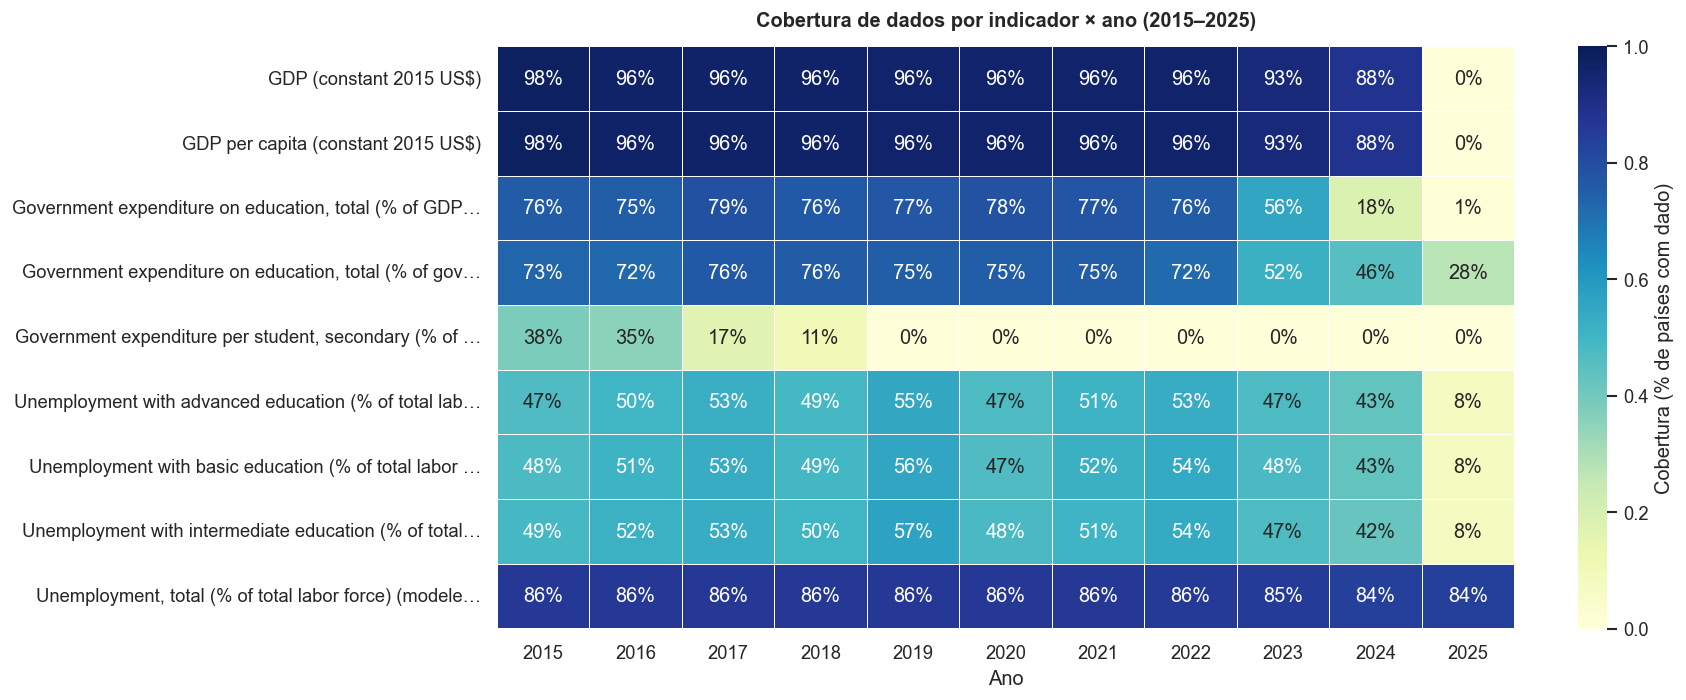

In [121]:
nomes_series = df['Series Name'].dropna().unique()
cob_records  = []
for s in nomes_series:
    sub = df[df['Series Name'] == s]
    for ano in ANOS:
        cob_records.append({
            'Série': s[:52] + '…' if len(s) > 52 else s,
            'Ano'  : ano[:4],
            'Cobertura': sub[ano].notna().mean()
        })

pivot_cob = (
    pd.DataFrame(cob_records)
    .pivot(index='Série', columns='Ano', values='Cobertura')
)

fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(
    pivot_cob, annot=True, fmt='.0%', cmap='YlGnBu',
    vmin=0, vmax=1, linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Cobertura (% de países com dado)'}
)
ax.set_title('Cobertura de dados por indicador × ano (2015–2025)',
             fontweight='bold', pad=12)
ax.set_xlabel('Ano')
ax.set_ylabel('')
plt.tight_layout()
fig.savefig(OUTPUT_PNG / 'cobertura_dados_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

> **Leitura do heatmap:**
> - **2025** está completamente ausente para GDP e GDP per capita — o Banco Mundial ainda não divulgou esses dados.
> - **2023–2024** apresentam queda de cobertura relevante em gasto com educação e desemprego por escolaridade.
> - `Government expenditure per student` só tem cobertura razoável em 2015–2016; é praticamente nula a partir de 2018.
> - As variáveis de desemprego por nível de escolaridade cobrem ~50% dos países — limitação importante para os modelos.

---
## 2.3. Estatísticas descritivas das variáveis numéricas (2015–2025)

Para calcular as estatísticas, transformamos o dataset de **wide** para **long** (uma linha por país × ano × indicador). Isso permite agregar todas as observações disponíveis no período completo, independentemente do ano.

In [122]:
df_long = df.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=ANOS,
    var_name='ano_str',
    value_name='valor'
).dropna(subset=['valor', 'Series Name'])

df_long['year'] = df_long['ano_str'].str.extract(r'(\d{4})').astype(int)

print(f'Total de observações (país × ano × indicador): {len(df_long):,}')
print(f'Período coberto: {df_long["year"].min()}–{df_long["year"].max()}')

Total de observações (país × ano × indicador): 12,763
Período coberto: 2015–2025


In [123]:
desc = (
    df_long
    .groupby('Series Name')['valor']
    .describe(percentiles=[.25, .5, .75])
    .round(2)
)
desc.index = [s[:65] + '…' if len(s) > 65 else s for s in desc.index]
desc.to_csv(OUTPUT_TABELAS / 'estatisticas_descritivas_geral.csv', encoding='utf-8')
display(desc)

,count,mean,std,min,25%,50%,75%,max
GDP (constant 2015 US$),2065.0,4.103583e+11,1.823693e+12,36811936.08,6.859420e+09,2.793508e+10,1.945055e+11,2.256846e+13
GDP per capita (constant 2015 US$),2065.0,1.718837e+04,2.473922e+04,254.40,2.271200e+03,6.440830e+03,2.145144e+04,2.471702e+05
"Government expenditure on education, total (% of GDP)",1496.0,4.360000e+00,2.000000e+00,0.00,3.110000e+00,4.190000e+00,5.310000e+00,1.639000e+01
"Government expenditure on education, total (% of government expen…",1563.0,1.419000e+01,4.980000e+00,0.00,1.072000e+01,1.356000e+01,1.716000e+01,3.501000e+01
"Government expenditure per student, secondary (% of GDP per capit…",219.0,2.008000e+01,8.130000e+00,0.73,1.500000e+01,2.014000e+01,2.388000e+01,6.503000e+01
Unemployment with advanced education (% of total labor force with…,1094.0,7.040000e+00,5.850000e+00,0.24,3.220000e+00,4.950000e+00,9.030000e+00,4.397000e+01
Unemployment with basic education (% of total labor force with ba…,1108.0,9.820000e+00,7.780000e+00,0.03,4.140000e+00,8.200000e+00,1.286000e+01,4.653000e+01
Unemployment with intermediate education (% of total labor force …,1110.0,8.850000e+00,6.570000e+00,0.12,4.620000e+00,7.060000e+00,1.086000e+01,5.728000e+01
"Unemployment, total (% of total labor force) (modeled ILO estimat…",2043.0,7.490000e+00,5.800000e+00,0.10,3.530000e+00,5.540000e+00,9.850000e+00,3.647000e+01


### 2.3.1 Distribuição das variáveis de interesse — histogramas

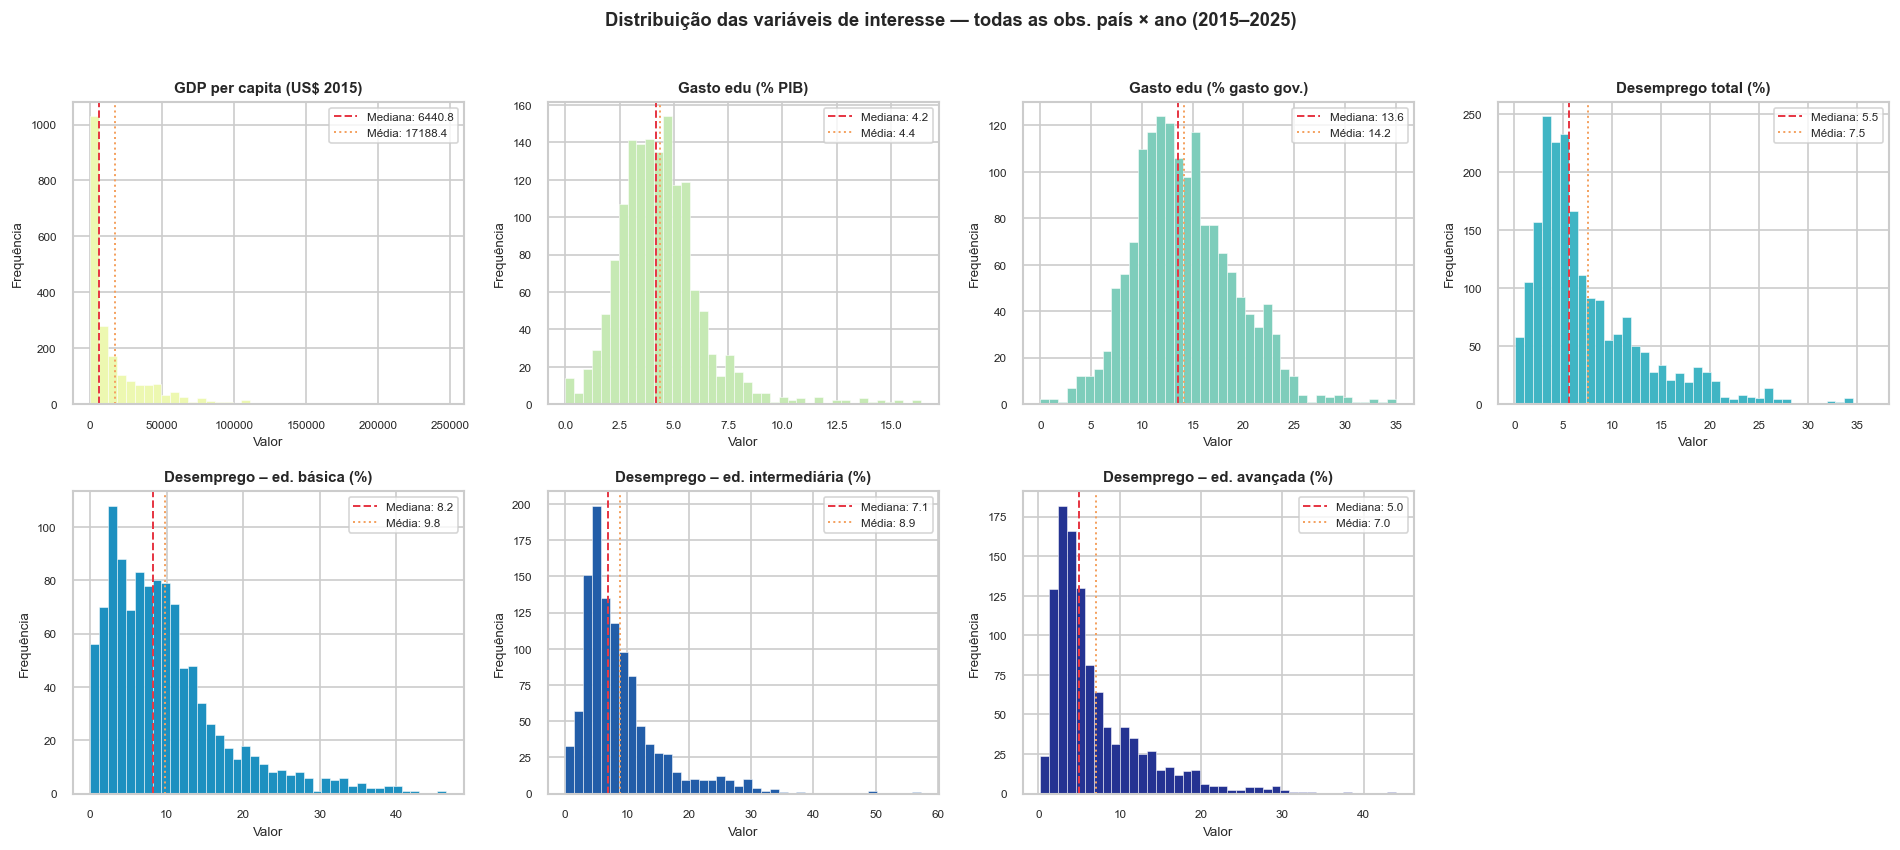

In [124]:
SERIES_INTERESSE = [
    'GDP per capita (constant 2015 US$)',
    'Government expenditure on education, total (% of GDP)',
    'Government expenditure on education, total (% of government expenditure)',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)',
    'Unemployment with basic education (% of total labor force with basic education)',
    'Unemployment with intermediate education (% of total labor force with intermediate education)',
    'Unemployment with advanced education (% of total labor force with advanced education)',
]
LABELS = [
    'GDP per capita (US$ 2015)',
    'Gasto edu (% PIB)',
    'Gasto edu (% gasto gov.)',
    'Desemprego total (%)',
    'Desemprego – ed. básica (%)',
    'Desemprego – ed. intermediária (%)',
    'Desemprego – ed. avançada (%)',
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
cores = sns.color_palette('YlGnBu', len(SERIES_INTERESSE))

for idx, (serie, label) in enumerate(zip(SERIES_INTERESSE, LABELS)):
    dados = df_long[df_long['Series Name'] == serie]['valor'].dropna()
    ax = axes[idx]
    ax.hist(dados, bins=40, color=cores[idx], edgecolor='white', linewidth=0.3)
    ax.axvline(dados.median(), color='#e63946', linestyle='--', linewidth=1.2,
               label=f'Mediana: {dados.median():.1f}')
    ax.axvline(dados.mean(), color='#f4a261', linestyle=':', linewidth=1.2,
               label=f'Média: {dados.mean():.1f}')
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=8)
    ax.set_ylabel('Frequência', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

axes[-1].set_visible(False)
fig.suptitle('Distribuição das variáveis de interesse — todas as obs. país × ano (2015–2025)',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_PNG / 'distribuicao_variaveis.png', dpi=150, bbox_inches='tight')
plt.show()

> **Observações:**
> - O **GDP per capita** tem distribuição fortemente assimétrica à direita (média muito acima da mediana). Nos modelos de regressão será utilizado em **log** para linearizar a relação e reduzir a influência de países muito ricos.
> - As variáveis de **desemprego** são aproximadamente simétricas, com alguns outliers acima de 30%.
> - **Gasto em educação** (% PIB) se concentra entre 3–6%, com poucos casos extremos.

### 2.3.2 Evolução temporal das principais variáveis (2015–2025)

Médias e medianas anuais para captar tendências e choques ao longo do período. Anos com poucos países são representados com linha tracejada para indicar menor confiabilidade.

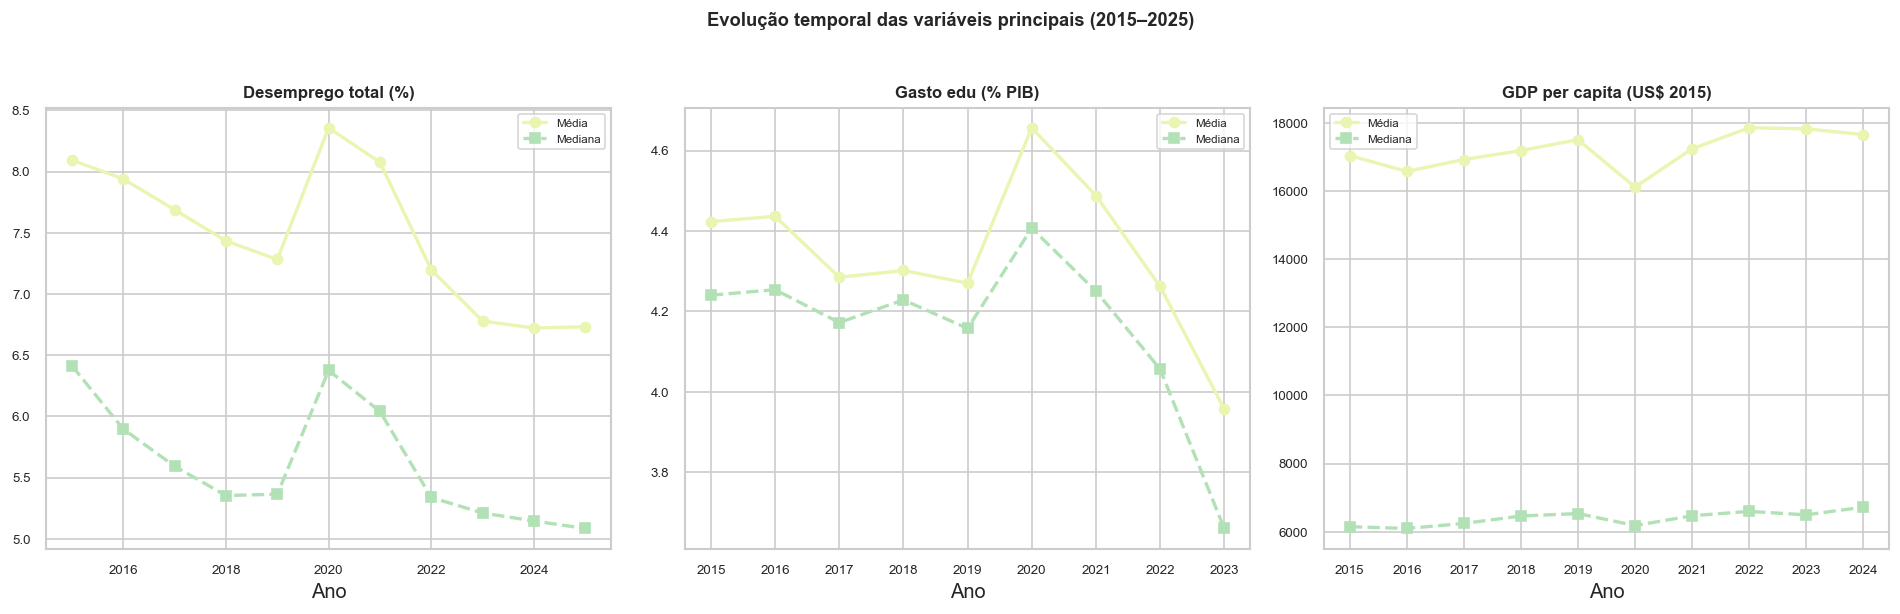

In [125]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pares = [
    ('Unemployment, total (% of total labor force) (modeled ILO estimate)',
     'Desemprego total (%)'),
    ('Government expenditure on education, total (% of GDP)',
     'Gasto edu (% PIB)'),
    ('GDP per capita (constant 2015 US$)',
     'GDP per capita (US$ 2015)'),
]

for ax, (serie, titulo) in zip(axes, pares):
    sub = df_long[df_long['Series Name'] == serie]
    agg = sub.groupby('year')['valor'].agg(['median', 'mean', 'count']).reset_index()

    # Anos com cobertura baixa (< 30% do máximo de países)
    limiar = agg['count'].max() * 0.3
    boa    = agg[agg['count'] >= limiar]
    fraca  = agg[agg['count'] <  limiar]

    ax.plot(boa['year'], boa['mean'],   marker='o', lw=2, label='Média')
    ax.plot(boa['year'], boa['median'], marker='s', lw=2, linestyle='--', label='Mediana')

    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel('Ano')
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle('Evolução temporal das variáveis principais (2015–2025)',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_PNG / 'evolucao_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

> O pico de desemprego em **2020** é visível e esperado (efeito COVID-19), seguido de recuperação em 2021–2022. O GDP per capita cai em 2020 e se recupera a partir de 2021. Os anos **2023–2025** aparecem em cinza por terem cobertura reduzida — as estatísticas nesses anos devem ser interpretadas com cautela.

### 2.3.3. Boxplots por ano — variação e outliers

Os histogramas mostram a distribuição agregada; os boxplots abaixo mostram como essa distribuição **varia a cada ano**, evidenciando outliers persistentes e mudanças de dispersão.

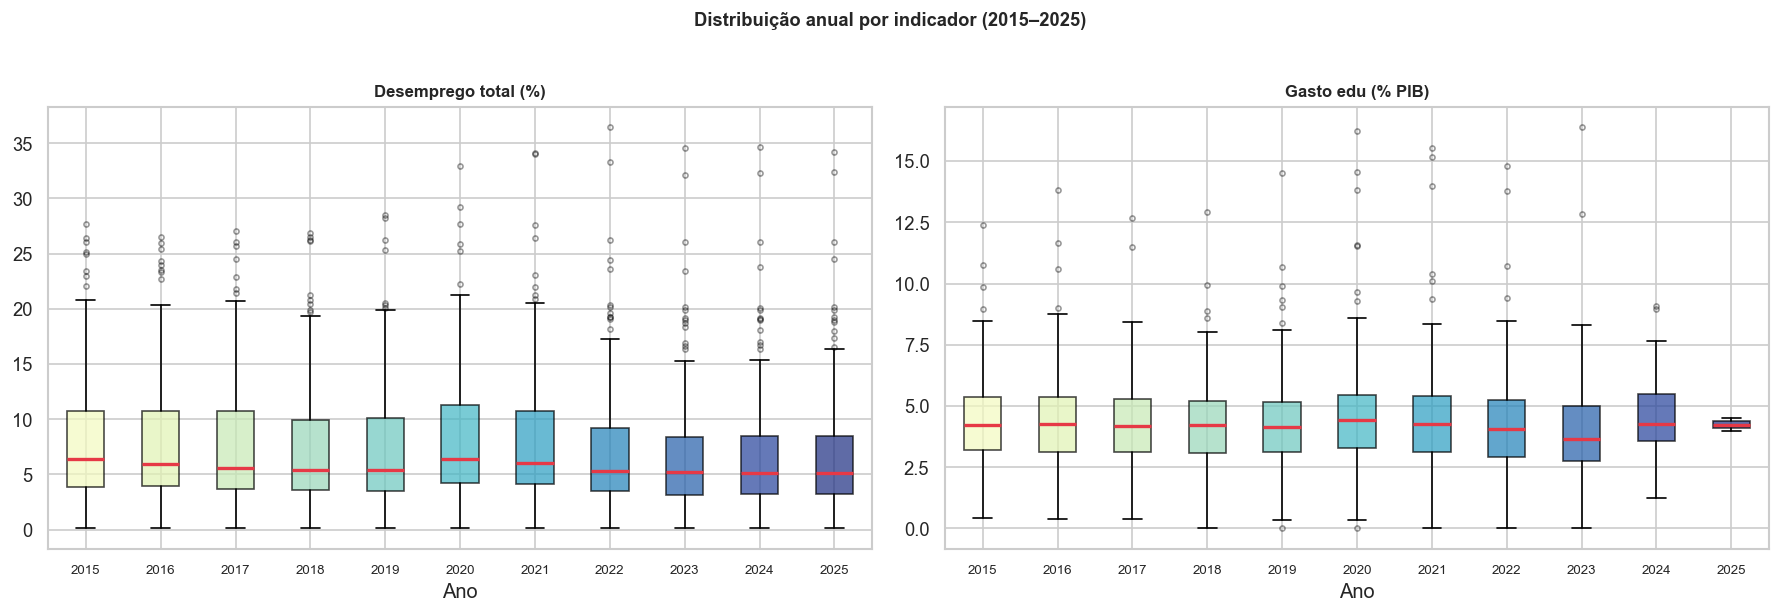

In [126]:
SERIES_BOX = [
    ('Unemployment, total (% of total labor force) (modeled ILO estimate)',
     'Desemprego total (%)'),
    ('Government expenditure on education, total (% of GDP)',
     'Gasto edu (% PIB)'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (serie, titulo) in zip(axes, SERIES_BOX):
    sub = df_long[df_long['Series Name'] == serie][['year', 'valor']].dropna()
    anos_ord = sorted(sub['year'].unique())
    dados_box = [sub[sub['year'] == a]['valor'].values for a in anos_ord]
    bp = ax.boxplot(dados_box, labels=anos_ord, patch_artist=True,
                    medianprops=dict(color='#e63946', linewidth=2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    cores_box = sns.color_palette('YlGnBu', len(anos_ord))
    for patch, cor in zip(bp['boxes'], cores_box):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.set_xlabel('Ano')
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Distribuição anual por indicador (2015–2025)',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_PNG / 'boxplots_anuais.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Limpeza dataset

In [127]:
# Configuração do dataset limpo que será gerado
#
# O dicionário define:
#   'arquivo_saida' : nome do CSV que será gravado
#   'anos_cols'     : lista de colunas de ano a processar (formato do Banco Mundial)
#
# Dataset gerado:
#   - dataset_metodos_2.csv: 2015–2025, período completo com todas as colunas
#                            de ano disponíveis no arquivo bruto.

CONFIGURACOES_LIMPEZA = [
    {
        'arquivo_saida': 'dataset_metodos_2.csv',
        'anos_cols': [
            '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]',
            '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]',
            '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]'
        ]
    },
]

# Leitura dataset_metodos.csv
with open(ARQUIVO, 'r', encoding='utf-8', errors='ignore') as arquivo_original:
    linhas_validas = [next(arquivo_original) for _ in range(1954)]
    # Captura exatamente as primeiras 1954 linhas: 1 de cabeçalho + 1953 de dados.
    # O arquivo bruto pode conter metadados ou linhas em branco após esse bloco
    # que corrompem o parsing; o corte explícito evita esse problema.

texto_completo = "".join(linhas_validas)
# Junta as linhas em uma string única que pode ser lida pelo pandas via io.StringIO.

df_bruto = pd.read_csv(io.StringIO(texto_completo))
# Faz o parsing do texto como se fosse um arquivo CSV, sem precisar gravar no disco.

df_bruto.columns = df_bruto.columns.str.strip()
# Remove espaços invisíveis nos nomes das colunas — problema comum em
# exportações do Banco Mundial.

# Loop de limpeza e gravação

for cfg in CONFIGURACOES_LIMPEZA:
    df = df_bruto.copy()
    # Trabalha sempre sobre uma cópia do DataFrame bruto para não acumular
    # transformações entre iterações.

    for col in cfg['anos_cols']:
        if col not in df.columns:
            continue
        # Pula silenciosamente colunas ausentes.

        df[col] = df[col].astype(str).str.strip()
        # Converte para string e remove espaços — etapa necessária antes
        # do replace, pois os valores podem ser float, int ou string.

        df[col] = df[col].str.replace('..', 'nan', regex=False)
        # Substitui o marcador de ausência do Banco Mundial ('..') pela
        # string 'nan', que o pandas reconhece na conversão seguinte.
        # regex=False é obrigatório: '..' em regex significa "qualquer
        # dois caracteres" e produziria substituições incorretas.

        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Converte para float. Qualquer valor não-numérico (incluindo 'nan'
        # e strings residuais) vira NaN real do numpy — o padrão correto
        # para representar ausência em análises quantitativas.

    df.to_csv(OUTPUT_SECUNDARIO / cfg['arquivo_saida'], index=False, encoding='utf-8')
    # Grava o dataset limpo sem o índice numérico do pandas (index=False),
    # em UTF-8 para preservar acentos e caracteres especiais nos nomes de países.

    print(f"✅ '{cfg['arquivo_saida']}' gerado com sucesso "
          f"({len(cfg['anos_cols'])} colunas de ano processadas).")

✅ 'dataset_metodos_2.csv' gerado com sucesso (11 colunas de ano processadas).


---
### 4. Análise novo dataset


════════════════════════════════════════════════════════════
  Diagnóstico: dataset_metodos_2.csv (2015–2025)
════════════════════════════════════════════════════════════
Relatório salvo: 'diagnostico_dados_faltantes_2015_2025.txt'


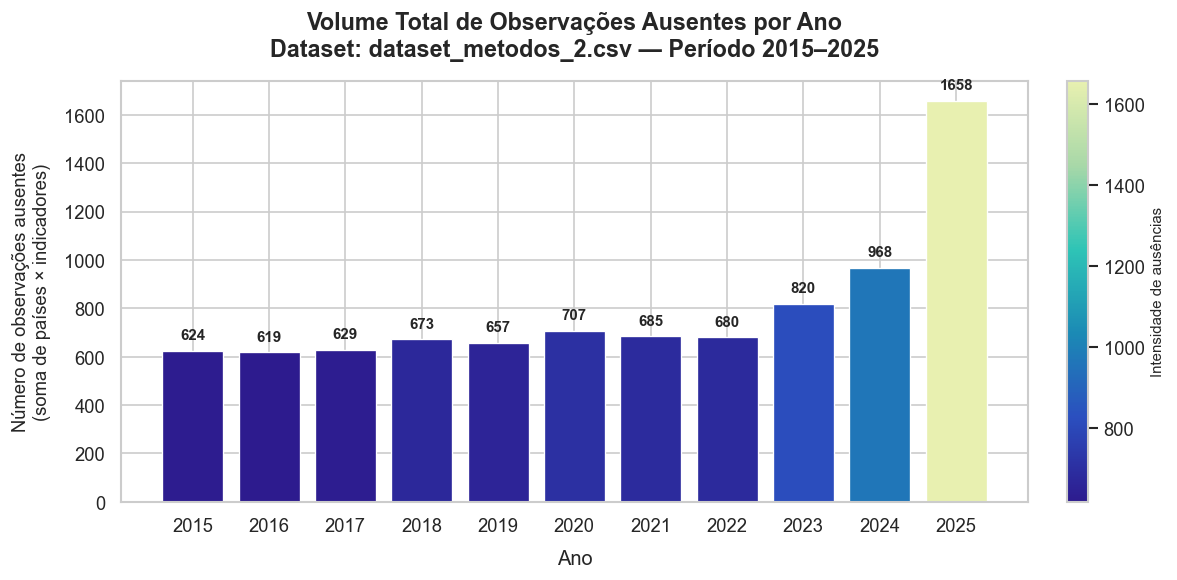

In [147]:
sns.set_theme(style="whitegrid")
# Define o tema visual padrão do Seaborn: fundo branco com grade cinza.

plt.rcParams['figure.figsize'] = (10, 6)
# Tamanho padrão para todas as figuras criadas a seguir (em polegadas).

# Paleta para gráficos
# Gradiente cool: azul escuro/roxo → azul → ciano → verde-água → amarelo claro.
# Mimetiza a barra de cores da imagem de referência (topo escuro, base clara).
CUSTOM_COLORS = ['#2D1B8E', '#2B4FBF', '#1B8AB5', '#2EC4B6', '#A8D8A8', '#E8F0B0']
CUSTOM_CMAP = mcolors.LinearSegmentedColormap.from_list('custom_cool', CUSTOM_COLORS)
# LinearSegmentedColormap interpola suavemente entre as cores da lista,
# gerando um mapa contínuo utilizável tanto em barras quanto em heatmaps.

def custom_palette(n):
    """Gera n cores discretas amostradas uniformemente da paleta personalizada."""
    return [CUSTOM_CMAP(i / max(n - 1, 1)) for i in range(n)]

# Configuração do dataset a auditar
CONFIGURACOES_DIAGNOSTICO = [
    {
        'arquivo':       'dataset_metodos_2.csv',
        # dataset_metodos_2.csv cobre 2015–2025; todas as colunas de ano
        # são utilizadas para o diagnóstico do período completo.
        'periodo':       '2015–2025',
        'sufixo':        '2015_2025',
        # Usado nos nomes dos arquivos de saída para identificar o período.
        'anos_cols': [
            '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]',
            '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]',
            '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]'
        ],
        'gerar_heatmap': True,
        # Heatmap de indicadores × anos ativado para este período.
    },
]


def executar_diagnostico(cfg):
    """
    Executa o diagnóstico completo de dados faltantes para um dataset.
    Para cada configuração, gera:
      1. Relatório TXT com países sem dados e países com dados parciais por ano.
      2. Gráfico de barras: volume de observações ausentes por ano.
      3. Heatmap indicadores × anos (opcional, conforme cfg['gerar_heatmap']).
    """
    # Carregamento de dados e preparação
    df = pd.read_csv(OUTPUT_SECUNDARIO / cfg['arquivo'], encoding='utf-8')
    df.columns = df.columns.str.strip()
    # Limpeza preventiva de espaços em nomes de colunas.

    anos_disponiveis = [col for col in cfg['anos_cols'] if col in df.columns]
    # Filtra apenas as colunas de ano que realmente existem no arquivo,
    # evitando KeyError caso o CSV não cubra todos os anos declarados.

    df['anos_com_dados'] = df[anos_disponiveis].notna().sum(axis=1)
    # Conta, linha por linha, quantas colunas de ano possuem valor não-nulo.
    # Varia de 0 (nenhum dado) a len(anos_disponiveis) (dados completos).

    df['total_anos_faltantes'] = len(anos_disponiveis) - df['anos_com_dados']
    # Complemento: quantos anos estão ausentes para cada linha (país × indicador).

    # 1. Relatório TXT sobre ausencias de dados

    nome_relatorio = f"diagnostico_dados_faltantes_{cfg['sufixo']}.txt"
    # Nome único por período, evitando sobrescrever relatórios de outros datasets.

    with open(OUTPUT_TXT / nome_relatorio, 'w', encoding='utf-8') as f:
        f.write(f"  DIAGNÓSTICO DE DADOS FALTANTES ({cfg['periodo']})\n")
        f.write("=" * 52 + "\n\n")

        # ── Seção 1: países sem absolutamente nenhum dado
        f.write("1. PAÍSES SEM NENHUM DADO NO PERÍODO\n")
        f.write("-" * 72 + "\n")
        totalmente_vazios = df[df['anos_com_dados'] == 0]
        # Filtra linhas onde todos os anos são NaN.

        if totalmente_vazios.empty:
            f.write("Nenhum país está completamente sem dados.\n")
        else:
            for _, row in totalmente_vazios.iterrows():
                f.write(f"País: {row['Country Name']:<40} | Indicador: {row['Series Name']}\n")

        f.write("\n" + "=" * 80 + "\n\n")

        # ── Seção 2: países com dados parciais — detalhe por ano ausente
        f.write("2. PAÍSES COM DADOS PARCIAIS (ANO A ANO)\n")
        f.write("-" * 72 + "\n")
        parcialmente_vazios = df[
            (df['anos_com_dados'] > 0) & (df['total_anos_faltantes'] > 0)
        ]
        # Intersecção: tem pelo menos um dado, mas falta pelo menos um ano.

        if parcialmente_vazios.empty:
            f.write("Nenhum país tem dados parciais — todos estão completos ou vazios.\n")
        else:
            for _, row in parcialmente_vazios.iterrows():
                anos_ausentes = [
                    col.split(' ')[0]          # Extrai "2015" de "2015 [YR2015]"
                    for col in anos_disponiveis
                    if pd.isna(row[col])       # Inclui apenas os anos com NaN
                ]
                anos_str = ", ".join(anos_ausentes)
                f.write(
                    f"País: {str(row['Country Name']):<35} | "
                    f"Indicador: {str(row['Series Name'])[:50]:<50} | "
                    f"Anos Ausentes: [{anos_str}]\n"
                )
    print(f"Relatório salvo: '{nome_relatorio}'")

# Gráfico de barras: observações ausentes por ano

    missing_por_ano = df[anos_disponiveis].isna().sum()
    # Conta NaNs coluna por coluna (ou seja, por ano), somando sobre todos
    # os países e indicadores.

    anos_limpos = [col.split(' ')[0] for col in anos_disponiveis]
    # Extrai apenas o número do ano para usar como rótulo no eixo X.

    valores = missing_por_ano.values
    norm = plt.Normalize(vmin=valores.min(), vmax=valores.max())
    cores_barras = [CUSTOM_CMAP(norm(v)) for v in valores]
    # Normaliza os valores para [0, 1] e mapeia cada um à paleta personalizada:
    # barras com mais ausências recebem o tom mais escuro (azul escuro/roxo).

    fig, ax1 = plt.subplots(figsize=(10, 5))
    bars = ax1.bar(anos_limpos, valores, color=cores_barras, edgecolor='white', linewidth=0.8)

    ax1.set_title(
        f'Volume Total de Observações Ausentes por Ano\n'
        f'Dataset: {cfg["arquivo"]} — Período {cfg["periodo"]}',
        fontsize=14, fontweight='bold', pad=15
    )
    ax1.set_xlabel('Ano', fontsize=12, labelpad=8)
    ax1.set_ylabel('Número de observações ausentes\n(soma de países × indicadores)', fontsize=11, labelpad=8)

    for bar, val in zip(bars, valores):
        ax1.annotate(
            f'{int(val)}',
            (bar.get_x() + bar.get_width() / 2., bar.get_height()),
            ha='center', va='bottom', xytext=(0, 5), textcoords='offset points',
            fontsize=9, fontweight='bold'
        )
    # Adiciona o valor exato no topo de cada barra.
    sm = plt.cm.ScalarMappable(cmap=CUSTOM_CMAP, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax1, orientation='vertical', fraction=0.03, pad=0.04)
    cbar.set_label('Intensidade de ausências', fontsize=9)
    # Colorbar lateral indica a correspondência cor → quantidade de ausências.

    plt.tight_layout()
    fig.savefig(OUTPUT_PNG / 'distribuicao_pos_limpeza.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Executa o diagnóstico para cada configuração ──────────────────────────────
for cfg in CONFIGURACOES_DIAGNOSTICO:
    print(f"\n{'═'*60}")
    print(f"  Diagnóstico: {cfg['arquivo']} ({cfg['periodo']})")
    print(f"{'═'*60}")
    executar_diagnostico(cfg)

### 5. Separação dos dados

### 5.1. Recorte temporal

Define os anos que serão usados nos 4 modelos (2015–2021), período com melhor cobertura simultânea dos indicadores de educação e desemprego. Anos posteriores a 2021 foram excluídos por apresentarem lacunas severas, especialmente noDefine os anos que serão usados nos 4 modelos (2015–2021), período com melhor

In [148]:
ANOS_ANALISE = [
    '2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]',
    '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]'
]

### 5.2.  Mapeamento de indicadores

 Mapeia chaves curtas (ex: 'Edu_PIB') para os nomes exatos dos indicadores encontrados no CSV, usando busca literal para evitar conflitos com caracteres como '(' e '%'. O print ao final confirma que todos os indicadores foram localizados antes de qualquer filtragem.

In [149]:
PALAVRAS_CHAVE = {
    'GDP':               'GDP (constant 2015 US$)',
    'GDP_pc':            'GDP per capita (constant 2015 US$)',
    'Edu_PIB':           'Government expenditure on education, total (% of GDP)',
    'Edu_Gov':           'Government expenditure on education, total (% of government expenditure)',
    'Unemp_Total':       'Unemployment, total (% of total labor force)',
    'Unemp_Advanced':    'Unemployment with advanced education',
    'Unemp_Basic':       'Unemployment with basic education',
    'Unemp_Intermediate':'Unemployment with intermediate education',
}
# O dicionário acima mapeia uma chave curta a um fragmento do nome do indicador.
 
nomes_reais_csv = {}
for chave, fragmento in PALAVRAS_CHAVE.items():
    matches = df[
        df['Series Name'].str.contains(fragmento, case=False, na=False, regex=False)
    ]['Series Name'].unique()
    # str.contains com regex=False: busca literal, sem interpretar '(' ou '%'
    # como metacaracteres de expressão regular.
 
    nomes_reais_csv[chave] = matches[0] if len(matches) > 0 else fragmento
    # Se não encontrar, usa o próprio fragmento como fallback (falha explícita
    # na filtragem, não silenciosa).
 
print(" Indicadores mapeados:")
for k, v in nomes_reais_csv.items():
    print(f"   {k:<22} → {v[:70]}")

 Indicadores mapeados:
   GDP                    → GDP (constant 2015 US$)
   GDP_pc                 → GDP per capita (constant 2015 US$)
   Edu_PIB                → Government expenditure on education, total (% of GDP)
   Edu_Gov                → Government expenditure on education, total (% of government expenditur
   Unemp_Total            → Unemployment, total (% of total labor force) (modeled ILO estimate)
   Unemp_Advanced         → Unemployment with advanced education (% of total labor force with adva
   Unemp_Basic            → Unemployment with basic education (% of total labor force with basic e
   Unemp_Intermediate     → Unemployment with intermediate education (% of total labor force with 


### 5.3.  Função de filtragem

 Define a função filtrar_e_salvar_dataset, que mantém apenas países com dados completos em todos os indicadores e anos exigidos. Países com qualquer lacuna são removidos e documentados em um relatório TXT com os anos ausentes por indicador

In [151]:
def filtrar_e_salvar_dataset(lista_chaves, nome_csv_saida, nome_relatorio_saida):
    """
    Filtra o dataset base mantendo apenas países que possuem dados completos
    (sem nenhum NaN) em todos os indicadores listados para todos os anos de
    2015 a 2021. Países com qualquer lacuna são removidos e documentados.
 
    Parâmetros
    lista_chaves         : list[str]
        Chaves do dicionário nomes_reais_csv que definem os indicadores
        obrigatórios para este dataset (ex: ['GDP', 'GDP_pc', 'Edu_PIB', 'Unemp_Total']).
    nome_csv_saida       : str
        Nome do arquivo CSV balanceado a gravar.
    nome_relatorio_saida : str
        Nome do arquivo TXT que detalha os países eliminados e seus motivos.
    """
 
    indicadores_alvo = [nomes_reais_csv[k] for k in lista_chaves]
    # Traduz as chaves curtas para os nomes exatos encontrados no CSV.
 
    todos_os_paises = df['Country Name'].dropna().unique()
    # Coleta todos os nomes de países distintos do dataset base.
 
    linhas_aprovadas   = []  # Linhas de países que passaram em todos os critérios
    eliminados_detalhe = {}  # {país: {indicador: [anos ausentes]}}
 
    for pais in todos_os_paises:
 
        # Filtro de nomes inválidos
        if (pais == ""
                or "Data from database" in pais
                or len(pais) > 50):
            continue
        # Descarta linhas de metadados do Banco Mundial (ex: "Data from database:
        # World Development Indicators") que aparecem no corpo do CSV.
 
        df_pais     = df[df['Country Name'] == pais]
        pais_ok     = True  # Assume válido; invalida ao encontrar primeiro problema
        erros_pais  = {}    # Erros acumulados por indicador
        linhas_pais = []    # Linhas válidas a adicionar se pais_ok permanecer True
 
        for ind in indicadores_alvo:
            df_ind = df_pais[df_pais['Series Name'] == ind]
 
            if df_ind.empty:
                # O indicador não existe para este país no arquivo base.
                pais_ok = False
                erros_pais[ind] = ['Indicador totalmente ausente no arquivo base']
                continue
                # Não interrompe o loop: continua coletando todos os erros
                # para documentar no relatório.
 
            anos_ausentes = [
                col.split(' ')[0]         # Extrai "2015" de "2015 [YR2015]"
                for col in ANOS_ANALISE
                if pd.isna(df_ind[col].values[0])
            ]
            # values[0]: acessa o único valor da célula (uma linha por indicador × país).
 
            if anos_ausentes:
                pais_ok = False
                erros_pais[ind] = anos_ausentes
            else:
                colunas_finais = ['Country Name', 'Country Code', 'Series Name'] + ANOS_ANALISE
                linhas_pais.append(df_ind[colunas_finais])
                # Guarda as linhas válidas; só serão aproveitadas se pais_ok = True ao final.
 
        if pais_ok and len(linhas_pais) == len(indicadores_alvo):
            linhas_aprovadas.extend(linhas_pais)
            # País completo: todas as linhas de todos os indicadores entram no dataset final.
        else:
            eliminados_detalhe[pais] = erros_pais
            # País eliminado: registra para o relatório.
 
    # Gravação do CSV balanceado
 
    if linhas_aprovadas:
        df_final = pd.concat(linhas_aprovadas, ignore_index=True)
        df_final.to_csv(OUTPUT_SECUNDARIO / nome_csv_saida, index=False, encoding='utf-8')
        n_paises = df_final['Country Name'].nunique()
        print(f" '{nome_csv_saida}' — {n_paises} países completos, "
              f"{len(indicadores_alvo)} indicadores, 7 anos (2015–2021).")
    else:
        print(f"  Nenhum país restou com dados completos para '{nome_csv_saida}'.")
 
    # Gerar relatório de países eliminados
 
    with open(OUTPUT_TXT / nome_relatorio_saida, 'w', encoding='utf-8') as f:
        f.write("=" * 52 + "\n")
        f.write(f"  PAÍSES ELIMINADOS — {nome_csv_saida.upper()}\n")
        f.write(f"  Critério: dados completos de 2015 a 2021\n")
        f.write("=" * 52 + "\n\n")
 
        for pais, dicionario_erros in sorted(eliminados_detalhe.items()):
            # sorted() garante ordem alfabética no relatório — facilita revisão manual.
            f.write(f"País: {pais}\n")
            for ind_nome, anos_list in dicionario_erros.items():
                anos_str = ", ".join(anos_list)
                f.write(
                    f"  → {ind_nome[:65]:<65} | Anos ausentes: [{anos_str}]\n"
                )
            f.write("-" * 95 + "\n")
 
    print(f" Relatório de eliminados salvo: '{nome_relatorio_saida}'")

### 5.4.  Execução
Chama a função quatro vezes, uma para cada combinação de indicador de gasto (% PIB ou % gasto governamental) e indicador de desemprego (total ou por escolaridade). Ao final, cada modelo possui seu próprio CSV balanceado  relatório de países eliminados.

In [155]:
print("\n── Dataset 1: Gasto (% PIB) × Desemprego Total ──")
filtrar_e_salvar_dataset(
    ['GDP', 'GDP_pc', 'Edu_PIB', 'Unemp_Total'],
    'dataset_modelo_1.csv',
    'relatorio_paises_eliminados_dataset_1.txt'
)
 
print("\n── Dataset 2: Gasto (% PIB) × Desemprego por Nível de Escolaridade ──")
filtrar_e_salvar_dataset(
    ['GDP', 'GDP_pc', 'Edu_PIB', 'Unemp_Advanced', 'Unemp_Basic', 'Unemp_Intermediate'],
    'dataset_modelo_2.csv',
    'relatorio_paises_eliminados_dataset_2.txt'
)
 
print("\n── Dataset 3: Gasto (% Gasto Governamental Total) × Desemprego Total ──")
filtrar_e_salvar_dataset(
    ['GDP', 'GDP_pc', 'Edu_Gov', 'Unemp_Total'],
    'dataset_modelo_3.csv',
    'relatorio_paises_eliminados_dataset_3.txt'
)
 
print("\n── Dataset 4: Gasto (% Gasto Governamental Total) × Desemprego por Nível de Escolaridade ──")
filtrar_e_salvar_dataset(
    ['GDP', 'GDP_pc', 'Edu_Gov', 'Unemp_Advanced', 'Unemp_Basic', 'Unemp_Intermediate'],
    'dataset_modelo_4.csv',
    'relatorio_paises_eliminados_dataset_4.txt'
)
 
print("\n Pipeline completo! Todos os datasets e relatórios foram gerados.")


── Dataset 1: Gasto (% PIB) × Desemprego Total ──
 'dataset_modelo_1.csv' — 125 países completos, 4 indicadores, 7 anos (2015–2021).
 Relatório de eliminados salvo: 'relatorio_paises_eliminados_dataset_1.txt'

── Dataset 2: Gasto (% PIB) × Desemprego por Nível de Escolaridade ──
 'dataset_modelo_2.csv' — 49 países completos, 6 indicadores, 7 anos (2015–2021).
 Relatório de eliminados salvo: 'relatorio_paises_eliminados_dataset_2.txt'

── Dataset 3: Gasto (% Gasto Governamental Total) × Desemprego Total ──
 'dataset_modelo_3.csv' — 114 países completos, 4 indicadores, 7 anos (2015–2021).
 Relatório de eliminados salvo: 'relatorio_paises_eliminados_dataset_3.txt'

── Dataset 4: Gasto (% Gasto Governamental Total) × Desemprego por Nível de Escolaridade ──
 'dataset_modelo_4.csv' — 47 países completos, 6 indicadores, 7 anos (2015–2021).
 Relatório de eliminados salvo: 'relatorio_paises_eliminados_dataset_4.txt'

 Pipeline completo! Todos os datasets e relatórios foram gerados.


### 6. Análise do Impacto do Gasto Público em Educação sobre o Desemprego

### 6.1. Configurações Globais

Carrega as bibliotecas necessárias (pandas, numpy, matplotlib, statsmodels e linearmodels) e define todas as constantes do projeto: caminhos de arquivo, colunas de anos, indicadores do Banco Mundial, paletas de cores e as 8 configurações de modelo (`MODELOS_CFG`). As paletas e configurações centralizadas aqui garantem consistência visual e de nomenclatura em todo o notebook.

In [157]:
## Configurações Globais
BASE_PATH   = str(OUTPUT_SECUNDARIO) + '/'  
OUTPUT_PATH = str(OUTPUT_TABELAS) + '/' 
ANOS = ['2015 [YR2015]', '2016 [YR2016]', '2017 [YR2017]',
        '2018 [YR2018]', '2019 [YR2019]', '2020 [YR2020]', '2021 [YR2021]']
# Lista com os nomes exatos das colunas de ano nos CSVs do Banco Mundial.
# O formato '[YRxxxx]' é padrão dos dados exportados do World Bank Data.
 
ANOS_ANALISE = ANOS[:-1]
# Subconjunto 2015–2020: exclui 2021 para evitar distorção na classificação
# de renda (dados mais incompletos e efeitos prolongados da pandemia de COVID-19).
 
IND_GDPPC = 'GDP per capita (constant 2015 US$)'
# Nome exato do indicador de PIB per capita (em dólares constantes de 2015)
# conforme aparece na coluna 'Series Name' do dataset base.
 
# ── Paleta personalizada baseada na imagem de referência ─────────────────────
# Gradiente cool: azul escuro/roxo → azul → ciano → verde-água → amarelo claro.
CUSTOM_COLORS = ['#2D1B8E', '#2B4FBF', '#1B8AB5', '#2EC4B6', '#A8D8A8', '#E8F0B0']
CUSTOM_CMAP   = mcolors.LinearSegmentedColormap.from_list('custom_cool', CUSTOM_COLORS)
# LinearSegmentedColormap interpola suavemente entre as cores da lista,
# gerando um mapa contínuo utilizável tanto em barras quanto em heatmaps.
 
# ── Paleta de cores por tercil de renda (usada nos scatter plots)
COR_Q = {
    'Q1 – Baixa renda': '#e74c3c',   # Vermelho — tercil inferior de PIB per capita
    'Q2 – Renda média': '#f39c12',   # Laranja — tercil intermediário
    'Q3 – Alta renda':  '#2ecc71',   # Verde — tercil superior
}
 
# ── Paleta de cores por especificação econométrica (usada no forest plot)
CORES_SPEC = {
    'OLS simples':  '#95a5a6',   # Cinza — modelo bivariado sem controles
    'OLS múltiplo': '#2980b9',   # Azul — OLS com controle de PIB per capita
    'OLS interação':'#8e44ad',   # Roxo — OLS com termo de interação edu × log(PIB)
}
 
## Configuração dos 8 Modelos Analisados
 
MODELOS_CFG = [
    # Cada dicionário define uma combinação de dataset, variável X, variável Y
    # e identificadores para o gráfico de dispersão gerado.
 
    dict(
        nome   ='M1 – Gasto público em educação (% do PIB) × Taxa de desemprego total',
        # Rótulo descritivo exibido nos títulos dos gráficos e tabelas.
        arquivo='dataset_modelo_1.csv',
        # Arquivo CSV contendo os dados para este modelo.
        x_col  ='Government expenditure on education, total (% of GDP)',
        # Nome exato da série do Banco Mundial usada como variável explicativa X.
        y_col  ='Unemployment, total (% of total labor force) (modeled ILO estimate)',
        # Nome exato da série do Banco Mundial usada como variável dependente Y.
        fig    ='dispersao_edu_pib_vs_desemp_total',
        # Prefixo do arquivo PNG de saída para este modelo.
    ),
    dict(
        nome   ='M2a – Gasto público em educação (% do PIB) × Taxa de desemprego com educação básica',
        arquivo='dataset_modelo_2.csv',
        x_col  ='Government expenditure on education, total (% of GDP)',
        y_col  ='Unemployment with basic education (% of total labor force with basic education)',
        fig    ='dispersao_edu_pib_vs_desemp_basico',
    ),
    dict(
        nome   ='M2b – Gasto público em educação (% do PIB) × Taxa de desemprego com educação intermediária',
        arquivo='dataset_modelo_2.csv',
        x_col  ='Government expenditure on education, total (% of GDP)',
        y_col  ='Unemployment with intermediate education (% of total labor force with intermediate education)',
        fig    ='dispersao_edu_pib_vs_desemp_intermediario',
    ),
    dict(
        nome   ='M2c – Gasto público em educação (% do PIB) × Taxa de desemprego com educação avançada',
        arquivo='dataset_modelo_2.csv',
        x_col  ='Government expenditure on education, total (% of GDP)',
        y_col  ='Unemployment with advanced education (% of total labor force with advanced education)',
        fig    ='dispersao_edu_pib_vs_desemp_avancado',
    ),
    dict(
        nome   ='M3 – Gasto público em educação (% do gasto governamental total) × Taxa de desemprego total',
        arquivo='dataset_modelo_3.csv',
        x_col  ='Government expenditure on education, total (% of government expenditure)',
        y_col  ='Unemployment, total (% of total labor force) (modeled ILO estimate)',
        fig    ='dispersao_edu_govtotal_vs_desemp_total',
    ),
    dict(
        nome   ='M4a – Gasto público em educação (% do gasto governamental total) × Taxa de desemprego com educação básica',
        arquivo='dataset_modelo_4.csv',
        x_col  ='Government expenditure on education, total (% of government expenditure)',
        y_col  ='Unemployment with basic education (% of total labor force with basic education)',
        fig    ='dispersao_edu_govtotal_vs_desemp_basico',
    ),
    dict(
        nome   ='M4b – Gasto público em educação (% do gasto governamental total) × Taxa de desemprego com educação intermediária',
        arquivo='dataset_modelo_4.csv',
        x_col  ='Government expenditure on education, total (% of government expenditure)',
        y_col  ='Unemployment with intermediate education (% of total labor force with intermediate education)',
        fig    ='dispersao_edu_govtotal_vs_desemp_intermediario',
    ),
    dict(
        nome   ='M4c – Gasto público em educação (% do gasto governamental total) × Taxa de desemprego com educação avançada',
        arquivo='dataset_modelo_4.csv',
        x_col  ='Government expenditure on education, total (% of government expenditure)',
        y_col  ='Unemployment with advanced education (% of total labor force with advanced education)',
        fig    ='dispersao_edu_govtotal_vs_desemp_avancado',
    ),
]

### 6.2. Levantamento de Países por Dataset

Lê os quatro arquivos CSV (`dataset_modelo_1` a `dataset_modelo_4`) e identifica o conjunto de países presentes em cada um deles. O resultado é a união de todos os países encontrados, que servirá de base para as etapas seguintes de classificação e filtragem.

In [159]:
## Passo 1 — Levantamento de países por dataset
print("═" * 65)
print("  PASSO 1 — Países nos 4 datasets")
print("═" * 65)
# Imprime cabeçalho decorativo no terminal para facilitar a leitura do log.
 
presenca = {}
# Dicionário que armazenará conjuntos (sets) de países presentes em cada dataset.
 
for i in range(1, 5):
    # Itera sobre os 4 datasets (dataset_modelo_1 a dataset_modelo_4).
 
    ds = pd.read_csv(f'{BASE_PATH}dataset_modelo_{i}.csv', encoding='utf-8')
    # Carrega o CSV correspondente em UTF-8.
 
    ds.columns = ds.columns.str.strip()
    # Remove espaços em branco extras nos nomes das colunas.
 
    ds['Country Name'] = ds['Country Name'].str.strip()
    # Remove espaços nos valores da coluna de nome do país.
 
    presenca[i] = set(ds['Country Name'].unique())
    # Armazena o conjunto de países únicos do dataset i.
 
    print(f"  DS{i}: {len(presenca[i])} países")
    # Exibe a contagem de países no terminal.
 
paises_uniao = sorted(presenca[1] | presenca[2] | presenca[3] | presenca[4])
# Calcula a união de todos os conjuntos: inclui qualquer país que apareça
# em pelo menos um dos 4 datasets. Ordena alfabeticamente.
 
print(f"  União total: {len(paises_uniao)} países\n")
# Exibe o total de países únicos considerados na análise.
# Salva tabela de países por dataset
df_presenca = pd.DataFrame({
    'Dataset': ['DS1', 'DS2', 'DS3', 'DS4', 'União total'],
    'Países': [len(presenca[1]), len(presenca[2]), len(presenca[3]), len(presenca[4]), len(paises_uniao)]
})
df_presenca.to_csv(OUTPUT_TABELAS / 'paises_por_dataset.csv', index=False, encoding='utf-8')
print('Tabela salva em:', OUTPUT_TABELAS / 'paises_por_dataset.csv')

═════════════════════════════════════════════════════════════════
  PASSO 1 — Países nos 4 datasets
═════════════════════════════════════════════════════════════════
  DS1: 125 países
  DS2: 49 países
  DS3: 114 países
  DS4: 47 países
  União total: 127 países

Tabela salva em: C:\Users\camin\Desktop\Trabalho_final_EAE1106-main\resultados\tabelas\paises_por_dataset.csv


### 6.3. PIB per Capita — Médio (2015–2020) e Anual (2015–2021)

Carrega o dataset auxiliar (`dataset_metodos_2.csv`) e extrai o PIB per capita em duas formas: uma média por país entre 2015 e 2020 (usada para definir os tercis de renda) e uma série anual de 2015 a 2021 em log (usada como variável de controle contínua nos modelos de painel). O ano de 2021 é excluído da média para evitar distorção gerada pela recuperação pós-pandemia.

In [160]:
## Passo 2 — PIB per capita: médio (2015–2020) e anual (2015–2021)
print("═" * 65)
print("  PASSO 2 — PIB per capita (médio para tercis + anual para seção cruzada)")
print("═" * 65)
 
df_base = pd.read_csv(f'{BASE_PATH}dataset_metodos_2.csv', encoding='utf-8')
# Lê o dataset auxiliar que contém indicadores macroeconômicos adicionais,
# incluindo o PIB per capita de todos os países.
 
df_base.columns = df_base.columns.str.strip()
df_base['Series Name']  = df_base['Series Name'].str.strip()
df_base['Country Name'] = df_base['Country Name'].str.strip()
# Limpa espaços extras em nomes de colunas e nas colunas-chave.
 
for col in ANOS:
    df_base[col] = pd.to_numeric(df_base[col], errors='coerce')
# Converte todas as colunas de ano para numérico.
# 'errors=coerce' transforma valores inválidos (ex: '..') em NaN.
 
mask_gdp = (
    df_base['Country Name'].isin(paises_uniao) &
    (df_base['Series Name'] == IND_GDPPC)
)
# Máscara booleana que seleciona apenas as linhas onde:
# (1) o país está na união dos 4 datasets E
# (2) o indicador é o PIB per capita em dólares constantes de 2015.
 
# ── 2a: PIB per capita médio 2015–2020 (usado para classificar os tercis)
# Remover 2021 pelo crescimento do pib em 21 ter ocorrido em grandes partes
# pela queda que a pandemia gerou em 20.
df_gdppc = (
    df_base[mask_gdp]
    .set_index('Country Name')[ANOS_ANALISE]
    # Usa apenas 2015–2020 para calcular a média (exclui 2021).
    .mean(axis=1)
    # Calcula a média entre os 6 anos, por país (eixo das colunas).
    .round(2)
    # Arredonda para 2 casas decimais.
    .reset_index()
    .rename(columns={0: 'GDP_pc_medio'})
    # Renomeia a coluna de valores para 'GDP_pc_medio'.
)
 
# ── 2b: PIB per capita médio como controle contínuo na seção cruzada
gdppc_anual = (
    df_base[mask_gdp]
    .set_index('Country Name')[ANOS]
    .stack()
    # Transforma de wide para long: cada linha = (país, ano).
    .reset_index()
    .rename(columns={'level_1': 'ano_str', 0: 'GDP_pc'})
)
gdppc_anual['year'] = gdppc_anual['ano_str'].str.extract(r'(\d{4})').astype(int)
# Extrai os 4 dígitos do ano da string '2015 [YR2015]' e converte para inteiro.
 
gdppc_anual['log_gdppc'] = np.log(gdppc_anual['GDP_pc'].replace(0, np.nan))
# Calcula log natural do PIB per capita. Zeros são substituídos por NaN
# para evitar log(0) = -infinito.
 
gdppc_anual = gdppc_anual[['Country Name', 'year', 'GDP_pc', 'log_gdppc']]
# Mantém apenas as colunas necessárias para o merge posterior.
 
print(f"  GDP_pc médio : {len(df_gdppc)} países")
print(f"  GDP_pc anual : {len(gdppc_anual)} obs. (país × ano)\n")

═════════════════════════════════════════════════════════════════
  PASSO 2 — PIB per capita (médio para tercis + anual para seção cruzada)
═════════════════════════════════════════════════════════════════
  GDP_pc médio : 127 países
  GDP_pc anual : 889 obs. (país × ano)



### 6.4. Classificação dos Países em Tercis de Renda

Divide os países em três grupos de tamanho igual (tercis) com base no PIB per capita médio de 2015–2020, usando `pd.qcut`. A tabela resultante, com país, PIB médio, tercil e datasets de origem, é salva em CSV e os limites de corte são exibidos para referência.

In [163]:
## Passo 3 — Classificação em Tercis de Renda
print("═" * 65)
print("  PASSO 3 — Classificação em tercis de PIB per capita")
print("═" * 65)
 
df_gdppc['quantil'] = pd.qcut(
    df_gdppc['GDP_pc_medio'], q=3,
    labels=['Q1 – Baixa renda', 'Q2 – Renda média', 'Q3 – Alta renda']
)
# Divide os países em 3 grupos de tamanho igual (tercis) com base no
# PIB per capita médio 2015–2020. Cada rótulo descreve o nível de renda.
 
df_gdppc['datasets'] = df_gdppc['Country Name'].apply(
    lambda p: ', '.join(f'DS{i}' for i in range(1, 5) if p in presenca[i])
)
# Para cada país, cria uma string listando em quais datasets ele aparece
# (ex: 'DS1, DS2, DS4').
 
df_gdppc = df_gdppc.sort_values(['quantil', 'GDP_pc_medio']).reset_index(drop=True)
# Ordena por tercil de renda e, dentro de cada tercil, por PIB crescente.
 
df_gdppc.to_csv(f'{OUTPUT_PATH}paises_classificados_por_tercil_de_renda.csv',
                index=False, encoding='utf-8')
# Salva a tabela com países, PIB médio, tercil e datasets em CSV.
 
lim = df_gdppc['GDP_pc_medio'].quantile([1/3, 2/3])
# Calcula os valores de corte nos percentis 33,3% e 66,6%.
 
print(f"  Limite Q1|Q2 : US$ {lim[1/3]:>10,.0f}")
print(f"  Limite Q2|Q3 : US$ {lim[2/3]:>10,.0f}\n")
# Exibe os valores monetários que separam os tercis.
 
for q in ['Q1 – Baixa renda', 'Q2 – Renda média', 'Q3 – Alta renda']:
    g = df_gdppc[df_gdppc['quantil'] == q]
    print(f"  {q}: {len(g)} países  |  média US$ {g['GDP_pc_medio'].mean():,.0f}")
# Imprime estatísticas resumidas (N e PIB médio) para cada tercil.
 
print(f"\n  → paises_classificados_por_tercil_de_renda.csv salvo com {len(df_gdppc)} países.\n")
 
mapa_quantil   = df_gdppc.set_index('Country Name')['quantil'].to_dict()
# Dicionário {país → tercil}: lookup rápido para atribuir o grupo a cada observação.
 
mapa_gdp_medio = df_gdppc.set_index('Country Name')['GDP_pc_medio'].to_dict()
# Dicionário {país → PIB per capita médio}: usado nos cálculos de log(PIB) médio.

═════════════════════════════════════════════════════════════════
  PASSO 3 — Classificação em tercis de PIB per capita
═════════════════════════════════════════════════════════════════
  Limite Q1|Q2 : US$      3,056
  Limite Q2|Q3 : US$     10,445

  Q1 – Baixa renda: 42 países  |  média US$ 1,342
  Q2 – Renda média: 42 países  |  média US$ 5,621
  Q3 – Alta renda: 43 países  |  média US$ 33,577

  → paises_classificados_por_tercil_de_renda.csv salvo com 127 países.



### 6.5. Heatmap — Distribuição de Países por Tercil e Dataset

Cria uma tabela pivô que cruza os tercis de renda com os quatro datasets, contando quantos países de cada tercil estão presentes em cada dataset. O resultado é visualizado como um heatmap com a paleta personalizada e salvo em PNG.

In [166]:
## Passo 4 — Heatmap de países por tercil e dataset
print("═" * 65)
print("  PASSO 4 — Heatmap")
print("═" * 65)
 
linhas_hm = [
    {'Quantil': str(row['quantil']), 'Dataset': f'DS{i}',
     'N': 1 if row['Country Name'] in presenca[i] else 0}
    for _, row in df_gdppc.iterrows()
    for i in range(1, 5)
]
# List comprehension que gera uma linha para cada combinação (país × dataset),
# com valor 1 se o país está no dataset e 0 caso contrário.
 
pivot_hm = (
    pd.DataFrame(linhas_hm)
    .pivot_table(index='Quantil', columns='Dataset', values='N', aggfunc='sum')
    # Tabela pivô: linhas = tercis de renda, colunas = datasets,
    # valores = contagem de países presentes.
    .reindex(['Q1 – Baixa renda', 'Q2 – Renda média', 'Q3 – Alta renda'])
    # Garante a ordem correta das linhas (de baixa para alta renda).
)
 
fig, ax = plt.subplots(figsize=(10, 5))
# Cria figura de 10×5 polegadas.
 
sns.heatmap(
    pivot_hm, annot=True, fmt='d',
    # annot=True: exibe os valores numéricos em cada célula.
    # fmt='d': formata como inteiro.
    cmap=CUSTOM_CMAP,
    # Paleta de cores personalizada (azul escuro → amarelo claro).
    linewidths=.5,
    # Espessura das bordas entre células.
    cbar_kws={
        'label': 'Número de países presentes no dataset',
        'shrink': 0.85
    },
    # Rótulo e tamanho da barra de cores lateral.
    ax=ax
)
 
ax.set_title(
    'Distribuição de países por tercil de renda e dataset\n'
    'Média do PIB per capita constante (US$ 2015) no período 2015–2020',
    fontsize=12, fontweight='bold', pad=12
)
# Título em duas linhas: primeira descreve o conteúdo, segunda indica o indicador e período.
 
ax.set_ylabel('Tercil de PIB per capita médio (2015–2020)', fontsize=10, labelpad=8)
ax.set_xlabel('Dataset de origem', fontsize=10, labelpad=8)
# Rótulos de eixo descritivos e com espaçamento adequado.
 
plt.tight_layout()
plt.savefig(OUTPUT_PNG / 'heatmap_distribuicao_paises_tercil_x_dataset.png',
            dpi=150, bbox_inches='tight')
# Salva o heatmap com nome descritivo do conteúdo.
plt.close()
print("  → heatmap_distribuicao_paises_tercil_x_dataset.png salvo\n")

═════════════════════════════════════════════════════════════════
  PASSO 4 — Heatmap
═════════════════════════════════════════════════════════════════
  → heatmap_distribuicao_paises_tercil_x_dataset.png salvo



### 6.6. Estatísticas Descritivas por Dataset

Para cada um dos quatro datasets, calcula média, mediana, mínimo, máximo e desvio padrão amostral de todas as variáveis relevantes (excluindo o PIB per capita, tratado separadamente). A tabela consolidada é renderizada como imagem PNG com estilização zebra e paleta por dataset.

In [168]:
## Passo 5 — Estatísticas Descritivas por Dataset
print("═" * 65)
print("  PASSO 5 — Estatísticas descritivas por dataset")
print("═" * 65)
# Gera, para cada um dos 4 datasets, uma tabela com média, mediana, mínimo,
# máximo e desvio padrão de todas as variáveis numéricas relevantes,
# excluindo o PIB per capita (coberto separadamente nos tercis de renda).
 
# ── Séries a excluir do resumo descritivo
EXCLUIR_SERIES = {IND_GDPPC}
# Conjunto de indicadores que não entram na tabela descritiva:
# o PIB per capita é tratado à parte (tercis, log, controle nos modelos).
 
# ── Abreviações para nomes longos de séries do Banco Mundial
ABREV_SERIES = {
    'Government expenditure on education, total (% of GDP)':
        'Gasto em educação (% PIB)',
    'Government expenditure on education, total (% of government expenditure)':
        'Gasto em educação (% gasto gov.)',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)':
        'Desemprego total (%)',
    'Unemployment with basic education (% of total labor force with basic education)':
        'Desemprego – Ed. básica (%)',
    'Unemployment with intermediate education (% of total labor force with intermediate education)':
        'Desemprego – Ed. intermediária (%)',
    'Unemployment with advanced education (% of total labor force with advanced education)':
        'Desemprego – Ed. avançada (%)',
}
# Dicionário de tradução: nome original do Banco Mundial → rótulo curto para a tabela.
# Séries não mapeadas receberão um truncamento automático de 45 caracteres.
 
def abreviar(nome):
    """Retorna o rótulo curto da série, ou trunca o nome original se não mapeado."""
    return ABREV_SERIES.get(nome, nome[:45] + ('…' if len(nome) > 45 else ''))
 
blocos_desc = []
# Lista que acumulará um DataFrame de estatísticas por dataset,
# para empilhamento final em uma única tabela.
 
for i in range(1, 5):
    ds = pd.read_csv(f'{BASE_PATH}dataset_modelo_{i}.csv', encoding='utf-8')
    ds.columns        = ds.columns.str.strip()
    ds['Series Name'] = ds['Series Name'].str.strip()
    ds[ANOS]          = ds[ANOS].apply(pd.to_numeric, errors='coerce')
    # Carrega e limpa o dataset i, convertendo colunas de ano para numérico.
 
    series_ds = [s for s in ds['Series Name'].unique() if s not in EXCLUIR_SERIES]
    # Lista das séries disponíveis neste dataset, excluindo o PIB per capita.
 
    for serie in series_ds:
        vals = (
            ds[ds['Series Name'] == serie][ANOS]
            .values.flatten()
        )
        # Extrai todos os valores numéricos da série (todos os países × todos os anos)
        # em um array 1D — base para o cálculo das estatísticas descritivas.
 
        vals = vals[~np.isnan(vals)]
        # Remove NaNs: as estatísticas são calculadas apenas sobre observações válidas.
 
        if len(vals) == 0:
            continue
        # Pula séries completamente vazias neste dataset.
 
        blocos_desc.append({
            'Dataset':  f'DS{i}',
            'Variável': abreviar(serie),
            'N':        len(vals),
            'Média':    round(float(np.mean(vals)),   2),
            'Mediana':  round(float(np.median(vals)), 2),
            'Mín.':     round(float(np.min(vals)),    2),
            'Máx.':     round(float(np.max(vals)),    2),
            'DP':       round(float(np.std(vals, ddof=1)), 2),
            # ddof=1: desvio padrão amostral (divide por N-1), padrão em estatística inferencial.
        })
 
df_desc = pd.DataFrame(blocos_desc)
# Consolida todas as linhas em um único DataFrame.
 
print(df_desc.to_string(index=False))
# Exibe a tabela completa no terminal para inspeção rápida.
 
# ── Renderização da tabela como PNG ──────────────────────────────────────────
 
n_linhas = len(df_desc)
altura_fig = max(4, n_linhas * 0.42 + 2.0)
# Altura da figura proporcional ao número de linhas, com mínimo de 4 polegadas.
 
fig_t, ax_t = plt.subplots(figsize=(14, altura_fig))
ax_t.axis('off')
# Desativa os eixos: a figura serve apenas como tela para a tabela.
 
# ── Cabeçalho e valores para o objeto Table do Matplotlib
col_labels = list(df_desc.columns)
cell_text  = df_desc.astype(str).values.tolist()
# Converte todos os valores para string para exibição nas células.
 
tabela_mpl = ax_t.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)
tabela_mpl.auto_set_font_size(False)
tabela_mpl.set_fontsize(9)
tabela_mpl.auto_set_column_width(col=list(range(len(col_labels))))
# Ajusta automaticamente a largura de cada coluna ao conteúdo.
 
# ── Estilização: cabeçalho com cor escura da paleta, linhas alternadas em cinza claro
COR_HEADER = CUSTOM_COLORS[0]   # Azul escuro/roxo — cor de destaque do cabeçalho
COR_ALT    = '#F0F4F8'          # Cinza azulado muito claro — fundo das linhas ímpares
 
for (row_idx, col_idx), cell in tabela_mpl.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    # Borda cinza clara entre células para legibilidade.
 
    if row_idx == 0:
        # Linha de cabeçalho: fundo escuro, texto branco e negrito.
        cell.set_facecolor(COR_HEADER)
        cell.set_text_props(color='white', fontweight='bold')
    elif row_idx % 2 == 0:
        # Linhas pares: fundo branco.
        cell.set_facecolor('white')
    else:
        # Linhas ímpares: fundo cinza azulado claro (zebra striping).
        cell.set_facecolor(COR_ALT)
 
    # ── Destaque da coluna 'Dataset': fundo levemente colorido para separação visual
    if col_idx == 0 and row_idx > 0:
        ds_val = df_desc.iloc[row_idx - 1]['Dataset']
        ds_num = int(ds_val.replace('DS', ''))
        # Extrai o número do dataset (1 a 4) para mapear à paleta.
        cor_ds = CUSTOM_CMAP((ds_num - 1) / 3)
        # Mapeia DS1→0.0, DS2→0.33, DS3→0.67, DS4→1.0 na paleta personalizada.
        r, g, b, _ = cor_ds
        cell.set_facecolor((r, g, b, 0.18))
        # Aplica a cor com baixa opacidade (18%) para não competir com o texto.
 
fig_t.suptitle(
    'Estatísticas Descritivas por Dataset\n'
    '(Média, Mediana, Mínimo, Máximo e Desvio Padrão — PIB per capita excluído)',
    fontsize=12, fontweight='bold', y=0.98
)
# Título acima da tabela, em duas linhas.
df_desc.to_csv(OUTPUT_TABELAS / 'estatisticas_descritivas_por_dataset.csv', index=False, encoding='utf-8')
plt.tight_layout()
plt.savefig(OUTPUT_PNG / 'tabela_estatisticas_descritivas_por_dataset.png',
            dpi=200, bbox_inches='tight')
plt.close()
print("\n  → tabela_estatisticas_descritivas_por_dataset.png salvo\n")

═════════════════════════════════════════════════════════════════
  PASSO 5 — Estatísticas descritivas por dataset
═════════════════════════════════════════════════════════════════
Dataset                           Variável   N        Média      Mediana         Mín.         Máx.           DP
    DS1            GDP (constant 2015 US$) 875 4.620760e+11 5.110454e+10 2.599996e+08 2.081610e+13 1.837242e+12
    DS1          Gasto em educação (% PIB) 875 4.340000e+00 4.260000e+00 3.600000e-01 1.152000e+01 1.630000e+00
    DS1               Desemprego total (%) 875 6.980000e+00 5.200000e+00 5.300000e-01 3.415000e+01 5.410000e+00
    DS2            GDP (constant 2015 US$) 343 9.319642e+11 2.534338e+11 7.797667e+09 2.081610e+13 2.780686e+12
    DS2          Gasto em educação (% PIB) 343 4.800000e+00 4.680000e+00 9.600000e-01 8.580000e+00 1.410000e+00
    DS2      Desemprego – Ed. avançada (%) 343 5.390000e+00 4.150000e+00 1.000000e+00 2.136000e+01 3.800000e+00
    DS2        Desemprego – Ed. bás

### 6.7.  Funções Auxiliares

Define as funções reutilizadas no loop principal: `build_panel` (constrói o painel país × ano com defasagens e dummy COVID), `cross_section` (agrega para seção transversal com termo de interação), `vif_table` (calcula VIF para diagnóstico de multicolinearidade), `ols_fit` (estima OLS via statsmodels), `aic_bic_row` / `print_ols_summary` / `print_panel_summary` (reportam métricas de ajuste), `coef_ci` (extrai coeficiente e intervalo de confiança) e `scatter_plot` (gera o gráfico de dispersão completo).

In [171]:
## Funções Auxiliares
 
### `build_panel` — Constrói o painel de dados
def build_panel(filename, x_col, y_col):
    """
    Lê o CSV e constrói um DataFrame em painel (país × ano) com as colunas:
      edu           — gasto público em educação (variável X)
      desemp        — taxa de desemprego (variável Y)
      log_gdppc     — log do PIB per capita anual (controle contínuo)
      log_gdppc_med — log do PIB per capita médio 2015–2020 (seção cruzada)
      quantil       — tercil de renda do país
    """
    df = pd.read_csv(OUTPUT_SECUNDARIO / filename, encoding='utf-8')
    df.columns         = df.columns.str.strip()
    df['Series Name']  = df['Series Name'].str.strip()
    df['Country Name'] = df['Country Name'].str.strip()
    df[ANOS] = df[ANOS].apply(pd.to_numeric, errors='coerce')
    # Carrega e limpa o CSV, convertendo os anos para numérico.
 
    def melt_s(serie, varname):
        # Filtra uma série específica e converte de formato wide (colunas por ano)
        # para formato long (uma linha por país-ano).
        sub = df[df['Series Name'] == serie].melt(
            id_vars=['Country Name', 'Country Code'],
            value_vars=ANOS, var_name='ano_str', value_name=varname
        )
        sub['year'] = sub['ano_str'].str.extract(r'(\d{4})').astype(int)
        # Extrai o ano numérico da string '2015 [YR2015]'.
        return sub[['Country Name', 'Country Code', 'year', varname]]
 
    panel = (melt_s(x_col, 'edu')
             .merge(melt_s(y_col, 'desemp'),
                    on=['Country Name', 'Country Code', 'year']))
    # Junta as séries X (edu) e Y (desemp) em um único DataFrame por país-ano.
 
    panel = panel.merge(gdppc_anual, on=['Country Name', 'year'], how='left')
    # Adiciona o PIB per capita anual (e seu log) como variável de controle.
 
    panel['quantil']       = panel['Country Name'].map(mapa_quantil).astype(str)
    # Atribui o tercil de renda a cada observação via lookup no dicionário.
 
    panel['log_gdppc_med'] = np.log(
        panel['Country Name'].map(mapa_gdp_medio).replace(0, np.nan)
    )
    # Calcula o log do PIB per capita médio (constante por país, para seção cruzada).
 
    panel = panel.sort_values(['Country Name', 'year']).reset_index(drop=True)
    # Ordena por país e ano.
 
    return panel
 
 
### `cross_section` — Colapsa para seção transversal
def cross_section(panel):
    """
    Agrega o painel calculando a média por país, produzindo uma seção
    transversal com uma observação por país (média ao longo dos anos).
    Também cria o termo de interação edu × log(PIB per capita médio).
    """
    cs = (
        panel.groupby('Country Name')
        .agg(
            edu=('edu', 'mean'),           # Média do gasto em educação
            desemp=('desemp', 'mean'),     # Média da taxa de desemprego
            log_gdppc_med=('log_gdppc_med', 'first'),  # Constante por país
            quantil=('quantil', 'first')   # Tercil de renda (constante por país)
        )
        .dropna()
        # Remove países com qualquer valor ausente nas variáveis de interesse.
        .reset_index()
    )
    cs['edu_x_logGDP'] = cs['edu'] * cs['log_gdppc_med']
    # Cria o termo de interação multiplicativo entre gasto em educação e
    # log(PIB per capita médio), usado no modelo OLS com interação.
    return cs
 
 
### `vif_table` — Calcula o VIF
def vif_table(X_df):
    """
    Calcula o Fator de Inflação da Variância (VIF) para cada coluna
    do DataFrame de variáveis explicativas.
    VIF > 5: multicolinearidade moderada.
    VIF > 10: multicolinearidade severa.
    """
    Xc = sm.add_constant(X_df)
    # Adiciona coluna de constante (intercepto), necessária para o cálculo do VIF.
    return pd.DataFrame({
        'Variável': X_df.columns,
        'VIF': [round(variance_inflation_factor(Xc.values, i + 1), 3)
                for i in range(X_df.shape[1])]
        # Calcula VIF para cada variável (índice i+1 pula a constante na posição 0).
    })
 
 
### `ols_fit` — Estima OLS
def ols_fit(Y, X_df):
    """
    Estima um modelo de Mínimos Quadrados Ordinários (OLS) via statsmodels,
    adicionando automaticamente a constante (intercepto) ao conjunto de regressores.
    Retorna o objeto de resultado completo do statsmodels.
    """
    return sm.OLS(Y, sm.add_constant(X_df)).fit()
 
 
### `aic_bic_row` — Coleta métricas de ajuste
def aic_bic_row(spec, modelo_nome, m):
    """
    Extrai as principais métricas de ajuste de um modelo OLS e retorna
    como dicionário, para posterior consolidação na tabela comparativa.
    Inclui: N, número de parâmetros (k), R², R² ajustado, AIC e BIC.
    """
    return {
        'Modelo':         modelo_nome,   # Nome do modelo (ex: M1, M2a...)
        'Especificação':  spec,           # Tipo de OLS (simples, múltiplo, interação)
        'N':              int(m.nobs),    # Número de observações usadas
        'k':              int(m.df_model), # Graus de liberdade do modelo (nº de regressores)
        'R²':             round(m.rsquared, 4),      # R² simples
        'R²_adj':         round(m.rsquared_adj, 4),  # R² ajustado (penaliza variáveis extras)
        'AIC':            round(m.aic, 2),  # Critério de Akaike (menor = melhor ajuste)
        'BIC':            round(m.bic, 2),  # Critério Bayesiano (penaliza mais parâmetros)
    }
 
 
### `print_ols_summary` — Imprime resumo do OLS no terminal
def print_ols_summary(tag, m, x_cols):
    sig_f = '✓' if m.f_pvalue < 0.05 else '✗'
    # Indica se o modelo como um todo é estatisticamente significativo (F-teste).
 
    print(f"\n    [{tag}]  N={int(m.nobs)}  R²={m.rsquared:.3f}  "
          f"R²adj={m.rsquared_adj:.3f}  AIC={m.aic:.1f}  BIC={m.bic:.1f}  "
          f"F-p={m.f_pvalue:.4f}{sig_f}")
    # Linha de cabeçalho com métricas gerais do modelo.
 
    for c in x_cols:
        b = m.params[c]; p = m.pvalues[c]
        sig = '✓' if p < 0.05 else '✗'
        label = c.replace('Government expenditure on education, total ', 'edu').split('(')[0].strip()[:55]
        # Abrevia o nome longo da variável para caber no terminal.
        print(f"       {label:<55}  β={b:+.4f}  p={p:.4f} {sig}")
        # Exibe coeficiente e p-valor de cada variável explicativa.
 
 
### `coef_ci` — Extrai coeficiente e intervalo de confiança
def coef_ci(model, col):
    """
    Retorna uma tupla (beta, ci_baixo, ci_alto, p-valor) para um
    coeficiente específico de um modelo OLS.
    """
    b  = model.params[col]
    p  = model.pvalues[col]
    ci = model.conf_int()
    lo = ci.loc[col, 0]
    hi = ci.loc[col, 1]
    return float(b), float(lo), float(hi), float(p)
 
 
### `scatter_plot` — Gráfico de dispersão (seção transversal)
def scatter_plot(cs, m_s, m_m, m_i, cfg, filename):
    """
    Gera o gráfico de dispersão da seção transversal (médias por país):
      • Pontos coloridos por tercil de renda (Q1, Q2, Q3)
      • Linha pontilhada cinza  : OLS simples (bivariado)
      • Linha tracejada azul   : OLS múltiplo com log(PIB) fixo na média
      • Banda sombreada        : Intervalo de confiança de 95% do OLS múltiplo
      • Linhas coloridas       : OLS com interação — uma reta por tercil
      • Caixa de estatísticas  : β, p-valor e R² dos 3 modelos
      • Rótulos dos outliers   : países com desemprego acima de Q3 + 1,5×IQR
    """
    fig, ax = plt.subplots(figsize=(12, 7))
 
    # ── Pontos: um por país, coloridos por tercil de renda
    for q, grp in cs.groupby('quantil'):
        cor = COR_Q.get(q, '#888')
        ax.scatter(grp['edu'], grp['desemp'],
                   c=cor, alpha=0.75, edgecolors='white', linewidths=0.5,
                   s=75, label=q, zorder=3)
        # alpha=0.75: leve transparência para pontos sobrepostos.
        # s=75: tamanho dos marcadores.
        # zorder=3: garante que os pontos ficam acima da grade.
 
    x_rng = np.linspace(cs['edu'].min(), cs['edu'].max(), 300)
    # Cria 300 pontos igualmente espaçados no intervalo de X, para desenhar linhas suaves.
 
    # ── Linha 1: OLS simples
    y_s = m_s.params['const'] + m_s.params['edu'] * x_rng
    ax.plot(x_rng, y_s, color='#95a5a6', linewidth=1.5, linestyle=':',
            label='OLS simples — sem controles', zorder=4)
 
    # ── Linha 2: OLS múltiplo (log(PIB) fixado na média da amostra)
    gdp_mean = cs['log_gdppc_med'].mean()
    y_m = (m_m.params['const']
           + m_m.params['edu'] * x_rng
           + m_m.params['log_gdppc_med'] * gdp_mean)
    ax.plot(x_rng, y_m, color='#2c3e50', linewidth=2, linestyle='--',
            label='OLS múltiplo — com controle de PIB per capita (na média)', zorder=5)
 
    # ── Banda de IC 95% ao redor da linha do OLS múltiplo
    pred_df = pd.DataFrame({'const': 1, 'edu': x_rng,
                             'log_gdppc_med': gdp_mean})
    ic = m_m.get_prediction(pred_df).summary_frame(alpha=0.05)
    ax.fill_between(x_rng, ic['mean_ci_lower'], ic['mean_ci_upper'],
                    color='#2c3e50', alpha=0.08,
                    label='Intervalo de confiança de 95% — OLS múltiplo')
 
    # ── Linhas do OLS com interação (uma por tercil)
    b0 = m_i.params['const']
    b1 = m_i.params['edu']
    b2 = m_i.params['log_gdppc_med']
    b3 = m_i.params['edu_x_logGDP']
    # b3 é o coeficiente do termo de interação edu × log(PIB): mede como
    # o efeito marginal do gasto em educação varia com o nível de renda.
    for q_nome in ['Q1 – Baixa renda', 'Q2 – Renda média', 'Q3 – Alta renda']:
        grp_q = cs[cs['quantil'] == q_nome]
        if grp_q.empty:
            continue
        gdp_q = grp_q['log_gdppc_med'].mean()
        # Usa o log(PIB) médio do tercil como ponto de avaliação da interação.
        y_int = b0 + (b1 + b3 * gdp_q) * x_rng + b2 * gdp_q
        # Efeito marginal de edu = b1 + b3 × log(PIB do tercil).
        ax.plot(x_rng, y_int, color=COR_Q[q_nome], linewidth=1.6,
                linestyle='-', alpha=0.55,
                label=f'OLS com interação — {q_nome}', zorder=4)
 
    # ── Rótulos de países outliers em Y (acima de Q3 + 1,5×IQR)
    q1_y  = cs['desemp'].quantile(0.25)
    q3_y  = cs['desemp'].quantile(0.75)
    lim_y = q3_y + 1.5 * (q3_y - q1_y)
    # Limite superior da "cerca" de Tukey: identifica outliers extremos em desemprego.
    for _, row in cs[cs['desemp'] > lim_y].iterrows():
        ax.annotate(row['Country Name'],
                    xy=(row['edu'], row['desemp']),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=7, color='#555')
        # Adiciona o nome do país próximo ao ponto outlier.
 
    # ── Caixa de estatísticas dos 3 modelos OLS
    def _s(m, col='edu'):
        b = m.params[col]; p = m.pvalues[col]
        sig = 'p < 0,05 ✓' if p < 0.05 else f'p = {p:.3f} ✗'
        return f"β = {b:+.3f}  {sig}  R² = {m.rsquared:.3f}"
 
    box = (
        f"N países = {int(m_s.nobs)}\n"
        f"\n[OLS simples — bivariado]\n  {_s(m_s)}\n"
        f"\n[OLS múltiplo — com log(PIB per capita)]\n"
        f"  β_edu    {_s(m_m)}\n"
        f"  β_logPIB β = {m_m.params['log_gdppc_med']:+.3f}  "
        f"{'p < 0,05 ✓' if m_m.pvalues['log_gdppc_med'] < .05 else 'p ≥ 0,05 ✗'}\n"
        f"\n[OLS com interação — edu × log(PIB)]\n"
        f"  β_edu    {_s(m_i)}\n"
        f"  β_inter  β = {m_i.params['edu_x_logGDP']:+.3f}  "
        f"{'p < 0,05 ✓' if m_i.pvalues['edu_x_logGDP'] < .05 else 'p ≥ 0,05 ✗'}  "
        f"R² = {m_i.rsquared:.3f}"
    )
    # Texto multilinha com resultados dos 3 modelos: coeficiente, significância e R².
 
    props = dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.92, edgecolor='#ccc')
    ax.text(0.98, 0.97, box, transform=ax.transAxes,
            fontsize=8, va='top', ha='right', bbox=props, family='monospace')
    # Insere a caixa de estatísticas no canto superior direito do gráfico.
 
    ax.set_xlabel('Gasto público em educação (% do PIB ou % do gasto governamental)',
                  fontsize=12, labelpad=8)
    ax.set_ylabel('Taxa de desemprego (%)', fontsize=12, labelpad=8)
    ax.set_title(cfg['nome'], fontsize=13, fontweight='bold', pad=14)
    # Usa o nome completo do modelo como título (definido em MODELOS_CFG).
 
    ax.legend(loc='upper left', fontsize=8.5, framealpha=0.88, ncol=2,
              title='Especificação do modelo / Tercil de renda',
              title_fontsize=8)
    # Legenda com duas colunas e título explicativo.
 
    ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.close()

### 6.8. Forest Plot — Comparação de Coeficientes entre Especificações

Consolida todos os coeficientes β do gasto em educação coletados no loop anterior e os exibe em um grid de subplots (um por modelo), com barras de intervalo de confiança de 95%, marcadores diferenciados por significância estatística e cores por especificação. O resultado é salvo como PNG e permite comparar visualmente a robustez do efeito estimado entre OLS, Pooled OLS e efeitos fixos.

In [173]:
## Passo 6 — Loop Principal: 8 Configurações × 3 Especificações OLS
 
print("═" * 65)
print("  PASSO 6 — Regressões OLS (simples, múltiplo e com interação)")
print("═" * 65)
 
cache_panels  = {}
# Cache de painéis já construídos: evita reler e reprocessar o mesmo
# CSV quando dois modelos compartilham o mesmo arquivo (ex: M2a, M2b, M2c).
 
tabela_resumo = []
# Lista que acumulará as métricas AIC/BIC de todos os modelos OLS,
# consolidada no final em um CSV comparativo.
 
coefs_forest  = []
# Lista que acumulará os coeficientes β, intervalos de confiança e
# p-valores de todos os modelos, para construção do forest plot.
 
for cfg in MODELOS_CFG:
    # Itera sobre as 8 configurações definidas em MODELOS_CFG.
 
    print(f"\n{'─'*65}")
    print(f"  {cfg['nome']}")
    print(f"{'─'*65}")
 
    chave = (cfg['arquivo'], cfg['x_col'], cfg['y_col'])
    if chave not in cache_panels:
        cache_panels[chave] = build_panel(cfg['arquivo'], cfg['x_col'], cfg['y_col'])
    panel = cache_panels[chave]
    # Se o painel para esta combinação já foi construído, reutiliza do cache.
 
    cs = cross_section(panel)
    if cs.empty or len(cs) < 5:
        print(" Dados insuficientes — ignorado.")
        continue
    # Pula configurações com menos de 5 países (mínimo para regressão).
 
    # ══ A) OLS SIMPLES: desemprego_médio ~ edu_médio
    m_s = ols_fit(cs['desemp'], cs[['edu']])
    print_ols_summary('OLS-simples', m_s, ['edu'])
    tabela_resumo.append({**aic_bic_row('OLS-simples', cfg['nome'], m_s),
                           'β_edu': round(m_s.params['edu'], 4),
                           'p_edu': round(m_s.pvalues['edu'], 4)})
    b, lo, hi, p = coef_ci(m_s, 'edu')
    coefs_forest.append(dict(cfg=cfg['nome'], spec='OLS simples',
                             b=b, lo=lo, hi=hi, p=p))
    # Estima, registra métricas, extrai coeficiente e adiciona ao forest plot.
 
    # ══ B) OLS MÚLTIPLO: desemprego_médio ~ edu_médio + log(PIB_médio)
    m_m = ols_fit(cs['desemp'], cs[['edu', 'log_gdppc_med']])
    print_ols_summary('OLS-múltiplo', m_m, ['edu', 'log_gdppc_med'])
 
    vif = vif_table(cs[['edu', 'log_gdppc_med']])
    vif_edu = vif.loc[vif['Variável'] == 'edu', 'VIF'].values[0]
    vif_gdp = vif.loc[vif['Variável'] == 'log_gdppc_med', 'VIF'].values[0]
    alerta  = '  ⚠ VIF > 5 — possível multicolinearidade moderada' if max(vif_edu, vif_gdp) > 5 else ''
    print(f"\n    VIF:  edu = {vif_edu:.2f}   log(PIB pc) = {vif_gdp:.2f}{alerta}")
    # Diagnóstico de multicolinearidade: VIF > 5 sugere correlação problemática
    # entre gasto em educação e PIB per capita.
 
    tabela_resumo.append({**aic_bic_row('OLS-múltiplo', cfg['nome'], m_m),
                           'β_edu': round(m_m.params['edu'], 4),
                           'p_edu': round(m_m.pvalues['edu'], 4)})
    b, lo, hi, p = coef_ci(m_m, 'edu')
    coefs_forest.append(dict(cfg=cfg['nome'], spec='OLS múltiplo',
                             b=b, lo=lo, hi=hi, p=p))
 
    # ══ C) OLS COM INTERAÇÃO: desemprego ~ edu + log(PIB) + edu × log(PIB)
    m_i = ols_fit(cs['desemp'], cs[['edu', 'log_gdppc_med', 'edu_x_logGDP']])
    print_ols_summary('OLS-interação', m_i,
                      ['edu', 'log_gdppc_med', 'edu_x_logGDP'])
    # O termo de interação testa se o efeito do gasto em educação sobre o
    # desemprego varia sistematicamente com o nível de desenvolvimento econômico.
 
    tabela_resumo.append({**aic_bic_row('OLS-interação', cfg['nome'], m_i),
                           'β_edu': round(m_i.params['edu'], 4),
                           'p_edu': round(m_i.pvalues['edu'], 4)})
    b, lo, hi, p = coef_ci(m_i, 'edu')
    coefs_forest.append(dict(cfg=cfg['nome'], spec='OLS interação',
                             b=b, lo=lo, hi=hi, p=p))
 
    print(f"\n    ── Comparação AIC/BIC (seção transversal) ──")
    print(f"       OLS simples  :  AIC = {m_s.aic:.1f}  BIC = {m_s.bic:.1f}")
    print(f"       OLS múltiplo :  AIC = {m_m.aic:.1f}  BIC = {m_m.bic:.1f}")
    print(f"       OLS interação:  AIC = {m_i.aic:.1f}  BIC = {m_i.bic:.1f}")
    melhor_aic = min([('simples', m_s.aic), ('múltiplo', m_m.aic),
                      ('interação', m_i.aic)], key=lambda x: x[1])
    print(f"       → Menor AIC (melhor ajuste): {melhor_aic[0]}")
    # AIC (Critério de Akaike) penaliza modelos com mais parâmetros:
    # o modelo com menor AIC oferece o melhor equilíbrio ajuste/parcimônia.
 
    # ── Salva o gráfico de dispersão desta configuração
    scatter_plot(cs, m_s, m_m, m_i, cfg,
             str(OUTPUT_PNG / f'{cfg["fig"]}_scatter.png'))
    print(f"\n  → {cfg['fig']}_scatter.png salvo")
 
# %%
## Passo 7 — Forest Plot com Resultado Geral Ponderado
 
# ─────────────────────────────────────────────────────────────────────────────
# COMO O RESULTADO GERAL É CALCULADO
# ─────────────────────────────────────────────────────────────────────────────
# Cada modelo estimado nos passos anteriores produziu:
#   b  = coeficiente β do gasto em educação
#   lo = limite inferior do IC 95%
#   hi = limite superior do IC 95%
#
# A partir do IC recuperamos o erro-padrão (SE) de cada estimativa:
#   SE_i = (hi_i − lo_i) / (2 × 1,96)
#   Raciocínio: o IC 95% de OLS é [β − 1,96·SE ; β + 1,96·SE],
#   portanto a largura total do intervalo é 2×1,96×SE → SE = largura/(2×1,96).
#
# Com o SE calculamos o PESO de cada estimativa pela ponderação por
# variância inversa (método padrão em meta-análise):
#   w_i = 1 / SE_i²
#   Estimativas mais precisas (SE menor) recebem peso maior.
#
# O β PONDERADO (pooled) de um grupo de estimativas é:
#   β_pool = Σ(w_i × β_i) / Σ(w_i)      ← média ponderada pelos pesos
#
# O SE do β ponderado é:
#   SE_pool = √(1 / Σ(w_i))
#
# O IC 95% do resultado ponderado é:
#   [β_pool − 1,96·SE_pool  ;  β_pool + 1,96·SE_pool]
#
# O p-valor é obtido pelo z-score:
#   z = β_pool / SE_pool
#   p = 2 × (1 − Φ(|z|))   onde Φ é a CDF da normal padrão
# ─────────────────────────────────────────────────────────────────────────────
 
from scipy import stats as scipy_stats
# Importa scipy.stats para usar a CDF da distribuição normal (cálculo do p-valor).
 
print(f"\n{'═'*65}")
print("  PASSO 7 — Forest plot + Resultado Geral Ponderado")
print("═" * 65)
 
df_f = pd.DataFrame(coefs_forest)
# Transforma a lista de dicionários coletada no loop em um DataFrame.
# Cada linha = um coeficiente β de um par (modelo, especificação).
# Colunas: cfg (nome do modelo), spec, b (β), lo (IC inf.), hi (IC sup.), p.
 
SPECS_ORDER = ['OLS simples', 'OLS múltiplo', 'OLS interação']
# Define a ordem de exibição das especificações no eixo Y:
# da mais simples (sem controles) para a mais complexa (com interação).
 
specs_disp = [s for s in SPECS_ORDER if s in df_f['spec'].values]
# Filtra apenas as especificações que foram de fato estimadas no loop.
# Evita referenciar specs ausentes caso algum modelo tenha falhado.
 
cfgs_uniq = [c['nome'] for c in MODELOS_CFG if c['nome'] in df_f['cfg'].values]
# Lista dos 8 nomes de modelos (M1–M4c) que geraram pelo menos um coeficiente.
# Mantém a ordem original de MODELOS_CFG para consistência visual.
 
n_cfg  = len(cfgs_uniq)
# Conta quantos modelos têm resultados — determina o número de subplots individuais.
 
n_spec = len(specs_disp)
# Conta quantas especificações foram estimadas — determina a altura de cada subplot.
 
# ── Passo 7a: Calcular SE e pesos para cada estimativa individual ─────────────
 
df_f['se'] = (df_f['hi'] - df_f['lo']) / (2 * 1.96)
# Recupera o erro-padrão de cada β a partir da largura do IC 95%.
# Fórmula: SE = (hi − lo) / (2 × 1,96), pois IC = [β ± 1,96·SE].
 
df_f['w'] = 1.0 / (df_f['se'] ** 2)
# Calcula o peso de cada estimativa pela ponderação por variância inversa.
# Estimativas com SE menor (mais precisas) recebem peso maior.
 
# ── Passo 7b: β ponderado por especificação ──────────────────────────────────
# Para cada tipo de especificação (OLS simples / múltiplo / interação),
# combina os 8 modelos em uma única estimativa pooled.
 
rows_por_spec = []
# Lista que acumulará o resultado ponderado de cada especificação.
 
for spec in specs_disp:
    # Itera sobre cada especificação econométrica disponível.
 
    sub_s = df_f[df_f['spec'] == spec].dropna(subset=['se', 'w'])
    # Seleciona apenas as linhas desta especificação e descarta NaN em se/w
    # (pode ocorrer se hi == lo, o que geraria SE = 0 e peso infinito).
 
    w_sum_s = sub_s['w'].sum()
    # Soma total dos pesos para esta especificação: Σ(w_i).
 
    b_pool_s = (sub_s['w'] * sub_s['b']).sum() / w_sum_s
    # β ponderado: Σ(w_i × β_i) / Σ(w_i).
    # É a média ponderada dos 8 coeficientes β desta especificação.
 
    se_pool_s = np.sqrt(1.0 / w_sum_s)
    # SE do β ponderado: √(1 / Σ(w_i)).
    # Quanto mais estimativas com alta precisão, menor o SE pooled.
 
    lo_pool_s = b_pool_s - 1.96 * se_pool_s
    # Limite inferior do IC 95% do resultado ponderado desta especificação.
 
    hi_pool_s = b_pool_s + 1.96 * se_pool_s
    # Limite superior do IC 95% do resultado ponderado desta especificação.
 
    z_s = b_pool_s / se_pool_s
    # z-score: razão entre o β ponderado e seu SE.
    # Quanto maior em valor absoluto, mais forte a evidência contra β = 0.
 
    p_pool_s = float(2 * (1 - scipy_stats.norm.cdf(abs(z_s))))
    # p-valor bilateral: probabilidade de observar |z| tão extremo sob H₀: β = 0.
    # Usa a CDF da normal padrão Φ: p = 2×(1 − Φ(|z|)).
 
    rows_por_spec.append({
        'spec':    spec,       # Nome da especificação (ex: 'OLS simples')
        'b':       b_pool_s,  # β ponderado desta especificação
        'lo':      lo_pool_s, # Limite inferior IC 95%
        'hi':      hi_pool_s, # Limite superior IC 95%
        'p':       p_pool_s,  # p-valor bilateral
        'se':      se_pool_s, # SE do β ponderado
        'n_modelos': len(sub_s), # Quantidade de modelos combinados
    })
 
df_pool_spec = pd.DataFrame(rows_por_spec)
# DataFrame com o β ponderado de cada especificação — usado no painel de resultado geral.
 
# ── Passo 7c: β ponderado GERAL (grand overall) ───────────────────────────────
# Combina TODOS os coeficientes (8 modelos × 3 especificações = 24 estimativas)
# em uma única estimativa resumo global.
 
df_f_clean = df_f.dropna(subset=['se', 'w'])
# Remove linhas com SE ou peso ausente antes do cálculo global.
 
w_sum_all = df_f_clean['w'].sum()
# Soma de todos os pesos: Σ(w_i) sobre os 24 coeficientes.
 
b_grand = (df_f_clean['w'] * df_f_clean['b']).sum() / w_sum_all
# β grand overall: média ponderada de todos os 24 coeficientes β.
 
se_grand = np.sqrt(1.0 / w_sum_all)
# SE do β grand overall: quanto mais estimativas, menor o SE resultante.
 
lo_grand = b_grand - 1.96 * se_grand
# Limite inferior do IC 95% do resultado geral.
 
hi_grand = b_grand + 1.96 * se_grand
# Limite superior do IC 95% do resultado geral.
 
z_grand = b_grand / se_grand
# z-score do β grand overall.
 
p_grand = float(2 * (1 - scipy_stats.norm.cdf(abs(z_grand))))
# p-valor bilateral do β grand overall.
 
sig_grand = 'p < 0,05 ✓' if p_grand < 0.05 else f'p = {p_grand:.3f} ✗'
# String de significância para exibir na caixa de texto do painel geral.
 
print(f"  β Grand Overall : {b_grand:+.4f}  SE = {se_grand:.4f}  "
      f"IC95% [{lo_grand:+.4f} ; {hi_grand:+.4f}]  {sig_grand}")
# Imprime o resultado geral no terminal para verificação rápida.
 
# ── Passo 7d: Montar a grade de subplots ─────────────────────────────────────
# A grade tem 9 subplots: 8 para os modelos individuais + 1 para o Resultado Geral.
 
ncols = 4
# Número fixo de colunas na grade de subplots.
 
n_total_slots = n_cfg + 1
# Total de subplots necessários: 8 modelos + 1 painel de resultado geral.
 
nrows = int(np.ceil(n_total_slots / ncols))
# Número de linhas da grade: arredondamento para cima de (9 / 4) = 3 linhas.
 
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(ncols * 4.5, nrows * (n_spec * 0.55 + 1.8))
)
# Cria a figura com grade nrows × ncols.
# Largura por coluna: 4,5 pol.; altura por linha: proporcional ao número de specs.
 
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]
# Transforma a grade 2D de eixos em lista 1D para facilitar a iteração por índice.
 
# ── Passo 7e: Subplots individuais (um por modelo) ───────────────────────────
 
for ax_idx, (ax, cfg_nome) in enumerate(zip(axes_flat, cfgs_uniq)):
    # Emparelha cada eixo da lista com o nome do modelo correspondente.
 
    sub = df_f[df_f['cfg'] == cfg_nome]
    # Filtra o DataFrame principal para conter apenas as linhas deste modelo.
 
    ax.axvline(0, color='black', linewidth=0.9)
    # Desenha linha vertical em x = 0: referência visual de "efeito nulo" (β = 0).
 
    for j, spec in enumerate(reversed(specs_disp)):
        # Enumera as especificações de baixo para cima (reversed):
        # j=0 → OLS interação (base do subplot), j=2 → OLS simples (topo).
 
        row = sub[sub['spec'] == spec]
        # Seleciona a linha do DataFrame com o β desta especificação neste modelo.
 
        if row.empty:
            continue
        # Pula se esta especificação não foi estimada para este modelo.
 
        b, lo, hi, p = row[['b', 'lo', 'hi', 'p']].values[0]
        # Extrai β, limites do IC e p-valor da linha selecionada como escalares.
 
        cor = CORES_SPEC.get(spec, '#888')
        # Recupera a cor definida em CORES_SPEC para esta especificação.
        # '#888' é cinza médio como fallback caso a spec não esteja no dicionário.
 
        marker = 'D' if p < 0.05 else 'o'
        # Define o marcador: losango (◆) se significativo (p < 0,05),
        # círculo (●) se não-significativo — convenção padrão em forest plots.
 
        ax.plot([lo, hi], [j, j], color=cor, linewidth=2.2, alpha=0.8)
        # Desenha a barra horizontal do IC 95% na posição vertical j.
        # [lo, hi] são os valores x; [j, j] mantém y constante (mesma linha).
 
        ax.scatter([b], [j], color=cor, s=55, zorder=5, marker=marker)
        # Plota o marcador do β estimado sobre a barra de IC.
        # zorder=5 garante que o ponto fica na frente da barra.
 
    ax.set_yticks(range(n_spec))
    # Define as posições dos ticks do eixo Y: 0, 1, 2 (uma por especificação).
 
    ax.set_yticklabels(list(reversed(specs_disp)), fontsize=8.5)
    # Rotula os ticks com os nomes das especificações (reversed para alinhar com o loop).
 
    titulo = cfg_nome.split('–', 1)[-1].strip()
    # Remove o prefixo "M1 –" do nome do modelo para deixar o título mais curto.
 
    titulo = '\n'.join([titulo[i:i+30] for i in range(0, len(titulo), 30)])
    # Quebra o título em pedaços de 30 caracteres separados por quebra de linha,
    # evitando que o texto ultrapasse a largura do subplot.
 
    ax.set_title(titulo, fontsize=9, fontweight='bold')
    # Aplica o título quebrado no subplot atual com fonte negrito tamanho 9.
 
    ax.set_xlabel('Coeficiente β — Gasto em Educação', fontsize=8)
    # Rótulo do eixo X descrevendo o que o valor representa.
 
    ax.grid(True, axis='x', linestyle='--', alpha=0.3)
    # Grade vertical tracejada com baixa opacidade para facilitar a leitura dos valores.
 
# ── Passo 7f: Painel do Resultado Geral (9º subplot) ─────────────────────────
 
ax_geral = axes_flat[n_cfg]
# Seleciona o 9º eixo (índice = 8) da lista achatada como painel de resultado geral.
 
ax_geral.axvline(0, color='black', linewidth=1.0)
# Linha de referência em β = 0 no painel de resultado geral.
 
for j, row_spec in enumerate(df_pool_spec.iloc[::-1].itertuples()):
    # Itera as linhas do DataFrame de resultados ponderados por spec, de baixo para cima.
    # iloc[::-1] inverte a ordem para que OLS simples apareça no topo.
 
    cor_s = CORES_SPEC.get(row_spec.spec, '#888')
    # Recupera a cor da especificação pelo dicionário CORES_SPEC.
 
    ax_geral.plot([row_spec.lo, row_spec.hi], [j + 1, j + 1],
                  color=cor_s, linewidth=2.5, alpha=0.85)
    # Desenha a barra de IC 95% do β ponderado desta especificação.
    # Posição vertical j+1: deixa j=0 reservado para o grand overall (abaixo).
 
    mk_s = 'D' if row_spec.p < 0.05 else 'o'
    # Losango se o β ponderado da especificação for significativo, círculo se não.
 
    ax_geral.scatter([row_spec.b], [j + 1],
                     color=cor_s, s=70, zorder=5, marker=mk_s)
    # Plota o β ponderado da especificação como marcador sobre a barra.
 
    ax_geral.text(
        ax_geral.get_xlim()[1] if ax_geral.get_xlim()[1] != 1.0 else row_spec.hi + 0.05,
        j + 1,
        f" β={row_spec.b:+.3f}  {('✓' if row_spec.p < 0.05 else '✗')}",
        va='center', fontsize=7.5, color=cor_s
    )
    # Anota o valor numérico do β ponderado à direita da barra para leitura direta.
 
# ── Grand Overall: desenhado como diamante preenchido na posição y = 0 ────────
 
diamond_hw = 0.35
# Meia-altura do diamante (half-height): controla o tamanho vertical da forma.
 
diamond_x = [lo_grand, b_grand, hi_grand, b_grand, lo_grand]
# Coordenadas X dos 5 vértices do diamante: extremo esq., centro, extremo dir.,
# centro de novo e retorno ao ponto inicial para fechar o polígono.
 
diamond_y = [0, diamond_hw, 0, -diamond_hw, 0]
# Coordenadas Y dos 5 vértices: centro, topo, centro, base, fechamento.
# Cria a forma de losango clássica dos forest plots de meta-análise.
 
ax_geral.fill(diamond_x, diamond_y,
              color='#1a1a2e', alpha=0.90, zorder=6)
# Preenche o polígono diamante com azul-marinho escuro e alta opacidade.
# zorder=6 garante que o diamante fique acima de todos os outros elementos.
 
ax_geral.plot([lo_grand, hi_grand], [0, 0],
              color='#1a1a2e', linewidth=2.5, zorder=5)
# Linha horizontal que acompanha o diamante, tornando o IC visualmente mais claro.
 
sig_txt = '✓' if p_grand < 0.05 else '✗'
# Símbolo de significância do resultado geral: ✓ se p < 0,05, ✗ caso contrário.
 
ax_geral.text(
    0.02, -0.18,
    f"β = {b_grand:+.4f}   SE = {se_grand:.4f}\n"
    f"IC 95%: [{lo_grand:+.4f} ; {hi_grand:+.4f}]\n"
    f"p = {p_grand:.4f}  {sig_txt}   N = {len(df_f_clean)} estimativas",
    transform=ax_geral.transAxes,
    fontsize=7.5, va='top', family='monospace',
    bbox=dict(boxstyle='round', facecolor='#f0f4f8', edgecolor='#aaa', alpha=0.95)
)
# Caixa de texto com todos os valores numéricos do grand overall.
# transform=ax.transAxes usa coordenadas relativas (0–1) em vez de dados.
 
n_labels = n_spec + 1
# Total de posições no eixo Y: n_spec posições para as specs + posição 0 para o grand overall.
 
ax_geral.set_yticks(range(n_labels))
# Define os ticks do eixo Y nas posições 0 (grand overall) a n_spec (specs).
 
ax_geral.set_yticklabels(
    ['◆ Grand Overall'] + list(reversed(specs_disp)),
    fontsize=8
)
# Rotula os ticks: posição 0 recebe "◆ Grand Overall", demais recebem os nomes das specs.
 
ax_geral.set_title('Resultado Geral\n(Ponderação por Variância Inversa)',
                   fontsize=9, fontweight='bold', color='#1a1a2e')
# Título do painel geral com método de ponderação explicitado.
 
ax_geral.set_xlabel('Coeficiente β ponderado — Gasto em Educação', fontsize=8)
# Rótulo do eixo X do painel geral.
 
ax_geral.grid(True, axis='x', linestyle='--', alpha=0.3)
# Grade vertical tracejada com baixa opacidade, igual aos subplots individuais.
 
ax_geral.set_ylim(-0.7, n_labels - 0.3)
# Ajusta os limites do eixo Y para dar espaço ao diamante e à caixa de texto.
 
# ── Passo 7g: Ocultar subplots extras da última linha ─────────────────────────
 
for ax in axes_flat[n_total_slots:]:
    ax.set_visible(False)
# Oculta os subplots vazios (posições 10 a 12 na última linha da grade de 3×4).
 
# ── Passo 7h: Legenda global ──────────────────────────────────────────────────
 
patches = [mpatches.Patch(color=CORES_SPEC[s], label=s) for s in specs_disp]
# Cria um patch colorido para cada especificação — elementos da legenda.
 
patches.append(mpatches.Patch(color='#1a1a2e', label='◆ Grand Overall'))
# Acrescenta o patch do grand overall à legenda com a cor azul-marinho do diamante.
 
fig.legend(
    handles=patches,
    loc='lower center',
    ncol=min(4, n_spec + 1),
    # Distribui os itens em até 4 colunas para caber horizontalmente.
    fontsize=9,
    framealpha=0.9,
    bbox_to_anchor=(0.5, -0.04),
    # Posiciona a legenda abaixo do centro da figura, fora da área de plotagem.
    title='Especificação econométrica',
    title_fontsize=9
)
 
fig.text(
    0.5, -0.01,
    '◆ = coeficiente estatisticamente significativo (p < 0,05)   '
    '● = coeficiente não-significativo (p ≥ 0,05)\n'
    'Barras horizontais = IC 95%.   '
    'Resultado Geral calculado por ponderação de variância inversa (w = 1/SE²).',
    ha='center', fontsize=8.5, color='#444'
)
# Nota de rodapé explicando símbolos, barras e método do resultado geral.
 
plt.suptitle(
    'Forest Plot — Coeficiente β do Gasto Público em Educação sobre a Taxa de Desemprego\n'
    'Comparação entre especificações OLS, grupos por nível educacional e resultado geral ponderado',
    fontsize=13, fontweight='bold', y=1.01
)
# Título completo da figura em duas linhas — descreve conteúdo e método resumo.
 
plt.tight_layout()
# Ajusta automaticamente os espaçamentos entre subplots para evitar sobreposição.
 
plt.savefig(OUTPUT_PNG / 'forest_plot_coeficientes_gasto_educacao_vs_desemprego.png',
            dpi=150, bbox_inches='tight')
# Salva a figura em PNG com resolução 150 dpi.
# bbox_inches='tight' inclui a legenda e nota de rodapé que estão fora da área padrão.
 
plt.close()
# Fecha a figura para liberar memória antes de gerar o próximo gráfico.
 
print("  → forest_plot_coeficientes_gasto_educacao_vs_desemprego.png salvo\n")

═════════════════════════════════════════════════════════════════
  PASSO 6 — Regressões OLS (simples, múltiplo e com interação)
═════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
  M1 – Gasto público em educação (% do PIB) × Taxa de desemprego total
─────────────────────────────────────────────────────────────────

    [OLS-simples]  N=125  R²=0.009  R²adj=0.001  AIC=772.7  BIC=778.4  F-p=0.2977✗
       edu                                                      β=+0.3266  p=0.2977 ✗

    [OLS-múltiplo]  N=125  R²=0.010  R²adj=-0.006  AIC=774.6  BIC=783.0  F-p=0.5374✗
       edu                                                      β=+0.2872  p=0.3834 ✗
       log_gdppc_med                                            β=+0.1424  p=0.6879 ✗

    VIF:  edu = 1.10   log(PIB pc) = 1.10

    [OLS-interação]  N=125  R²=0.021  R²adj=-0.004  AIC=775.2  BIC=786.5  F-p=0.4712✗
       edu                                 

### 6.9. Tabela Comparativa de Ajuste dos Modelos OLS

Consolida todas as métricas de ajuste coletadas ao longo do loop (N, k, R², R² ajustado, AIC, BIC, β_edu e p_edu) em um único DataFrame e o salva como CSV. Esta tabela permite comparar objetivamente qual especificação oferece o melhor equilíbrio entre ajuste e parcimônia para cada par de variáveis analisado.

In [175]:
## Passo 8 — Tabela Comparativa CSV (OLS)
 
df_resumo = pd.DataFrame(tabela_resumo)
# Consolida todas as linhas de métricas AIC/BIC em um único DataFrame.
 
df_resumo.to_csv(
    f'{OUTPUT_PATH}tabela_comparacao_ajuste_modelos_ols.csv',
    index=False, encoding='utf-8'
)
# Salva a tabela com nome descritivo: "tabela_comparacao_ajuste_modelos_ols.csv"
# Contém: modelo, especificação, N, k, R², R²adj, AIC, BIC, β_edu e p_edu.
 
print(f"  → tabela_comparacao_ajuste_modelos_ols.csv salvo "
      f"({len(df_resumo)} linhas × {len(df_resumo.columns)} colunas)")
 
print("\n" + "═" * 65)
print("  ✓ Análise concluída!  Arquivos gerados:")
print("═" * 65)
 
# ── Lista de todos os arquivos de saída com nomes descritivos
arqs = [
    'paises_classificados_por_tercil_de_renda.csv',
    'heatmap_distribuicao_paises_tercil_x_dataset.png',
    'tabela_estatisticas_descritivas_por_dataset.png',
    'forest_plot_coeficientes_gasto_educacao_vs_desemprego.png',
    'tabela_comparacao_ajuste_modelos_ols.csv',
] + [f"{c['fig']}_scatter.png" for c in MODELOS_CFG]
 
for a in arqs:
    print("\n  CSVs em:", OUTPUT_TABELAS)
print("  PNGs em:", OUTPUT_PNG)

  → tabela_comparacao_ajuste_modelos_ols.csv salvo (24 linhas × 10 colunas)

═════════════════════════════════════════════════════════════════
  ✓ Análise concluída!  Arquivos gerados:
═════════════════════════════════════════════════════════════════

  CSVs em: C:\Users\camin\Desktop\Trabalho_final_EAE1106-main\resultados\tabelas

  CSVs em: C:\Users\camin\Desktop\Trabalho_final_EAE1106-main\resultados\tabelas

  CSVs em: C:\Users\camin\Desktop\Trabalho_final_EAE1106-main\resultados\tabelas

  CSVs em: C:\Users\camin\Desktop\Trabalho_final_EAE1106-main\resultados\tabelas

  CSVs em: C:\Users\camin\Desktop\Trabalho_final_EAE1106-main\resultados\tabelas

  CSVs em: C:\Users\camin\Desktop\Trabalho_final_EAE1106-main\resultados\tabelas

  CSVs em: C:\Users\camin\Desktop\Trabalho_final_EAE1106-main\resultados\tabelas

  CSVs em: C:\Users\camin\Desktop\Trabalho_final_EAE1106-main\resultados\tabelas

  CSVs em: C:\Users\camin\Desktop\Trabalho_final_EAE1106-main\resultados\tabelas

  CSVs em: